In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pyspark.sql.functions import rand

spark = SparkSession \
    .builder \
    .master("local[*]") \
    .appName("UK Police") \
    .getOrCreate()

sc = spark.sparkContext

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/09 17:06:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
df_final = spark.read.parquet("data/processed_data.parquet").cache()

In [3]:
# Count total records
total_records = df_final.count()
print(f"Total number of search records: {total_records:,}")

# Show schema to understand available features
df_final.printSchema()

# Display a sample of the data
df_final.limit(5).toPandas()

[Stage 1:============================================>              (3 + 1) / 4]

Total number of search records: 1,403,329
root
 |-- age: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- law: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- dayofyear: integer (nullable = true)
 |-- dayofweek: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- ethnicity: string (nullable = true)
 |-- search_type: string (nullable = true)
 |-- reason: string (nullable = true)
 |-- police_force: string (nullable = true)
 |-- legal_action_taken: integer (nullable = true)



,age,gender,law,year,timestamp,dayofyear,dayofweek,hour,month,ethnicity,search_type,reason,police_force,legal_action_taken
0,10-17,Male,Misuse of Drugs Act 1971 (section 23),2025,2025-10-16 23:59:57,289,5,23,10,White,Person search,Controlled drugs,avon-and-somerset,0
1,18-24,Male,Unknown,2025,2025-10-28 17:06:01,301,3,17,10,Unknown,Person search,Unknown,avon-and-somerset,0
2,Unknown,Unknown,Firearms Act 1968 (section 47),2025,2025-10-22 00:35:59,294,3,0,10,Black,Person search,Firearms,avon-and-somerset,0
3,10-17,Male,Police and Criminal Evidence Act 1984 (section 1),2025,2025-10-23 17:36:34,296,5,17,10,Asian,Person search,Offensive weapons,avon-and-somerset,1
4,10-17,Male,Police and Criminal Evidence Act 1984 (section 1),2025,2025-10-07 21:53:17,280,3,21,10,White,Person search,Offensive weapons,avon-and-somerset,0


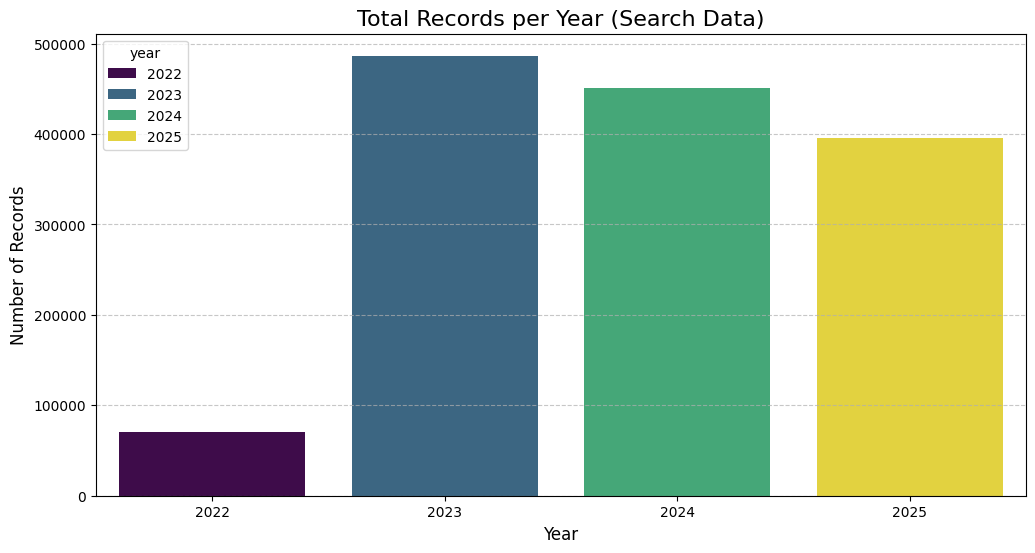

In [4]:
# 1. Filter out nulls (if any) and group by year
yearly_counts = (df_final
                 .filter(F.col("year").isNotNull())
                 .groupBy("year")
                 .count()
                 .orderBy("year"))

# 2. Convert the small aggregated result to Pandas for plotting
pdf = yearly_counts.toPandas()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=pdf, 
    x="year",  
    y="count", 
    palette="viridis", 
    hue="year", 
    legend=True
)
# Add labels and title
plt.title('Total Records per Year (Search Data)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Data Processing

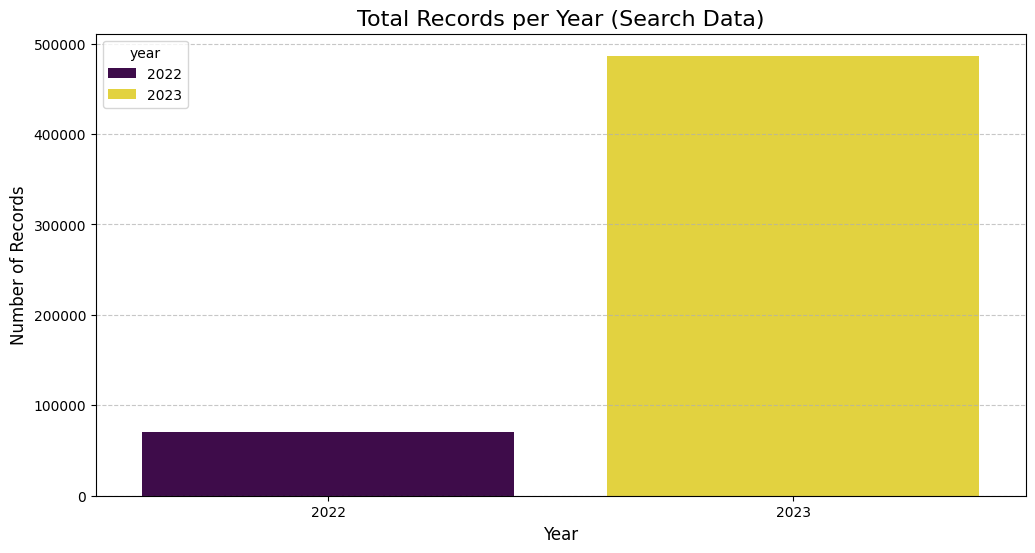

In [5]:
# 1. Filter out nulls (if any) and group by year
yearly_counts = (
    df_final
    .filter(F.col("year") < 2024)
    .groupBy("year")
    .count()
    .orderBy("year")
)

# 2. Convert the small aggregated result to Pandas for plotting
pdf = yearly_counts.toPandas()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=pdf, 
    x="year",  
    y="count", 
    palette="viridis", 
    hue="year", 
    legend=True
)
# Add labels and title
plt.title('Total Records per Year (Search Data)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Models training

In [6]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml import Pipeline
from dateutil.relativedelta import relativedelta
import time

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.functions import vector_to_array

In [7]:
years = sorted(
    df_final.select("year").distinct().rdd.map(lambda r: r.year).collect()
)

print(years[1:])

[Stage 24:>                                                         (0 + 1) / 1]

[2023, 2024, 2025]


In [8]:
categorical_cols = ["age", "gender", "law", "ethnicity", "search_type", "reason", "police_force"]
numeric_cols = ["hour", "month", "dayofweek", "dayofyear"]
feature_cols = [f"{col}_idx" for col in categorical_cols] + numeric_cols

In [9]:
neg_count = 2006
pos_count = 357
total = 2363

total = neg_count + pos_count
weight_for_0 = total / (2.0 * neg_count)  # Lower weight if more samples
weight_for_1 = total / (2.0 * pos_count)

print(0.58, 3.31)

0.58 3.31


In [10]:
def train_dt(
    train_df,
    categorical_cols,
    numeric_cols,
    feature_cols,
    normalized_weights = False,
    weight_multiplier = 2,
    model = "DT"
):
    # 1) Weight model
    class_counts = train_df.groupBy("legal_action_taken").count().collect()

    neg_count = [x['count'] for x in class_counts if x['legal_action_taken'] == 0][0]
    pos_count = [x['count'] for x in class_counts if x['legal_action_taken'] == 1][0]
    weight_ratio = neg_count / (neg_count+pos_count)
    
    print(f" Unbalance: {neg_count:,} negatives vs {pos_count:,} positives")
    print(f"   Ratio: {weight_ratio:.2f} vs {1-weight_ratio:.2f}")
    print()

    if normalized_weights:
        weighted_df= train_df.withColumn(
            "classWeight",
            F.when(F.col("legal_action_taken") == 1, weight_ratio).otherwise(1.0-weight_ratio)
        )

    else:
        # Weight for minority class should be HIGHER
        total = neg_count + pos_count
        weight_for_0 = total / (2.0 * neg_count)  # Lower weight if more samples
        weight_for_1 = total / (2.0 * pos_count)  # Higher weight if fewer samples
        
        print(f" Unbalance: {neg_count:,} negatives vs {pos_count:,} positives")
        print(f"   Weights: class_0={weight_for_0:.3f}, class_1={weight_for_1:.3f}")
        print()
        
        weighted_df = train_df.withColumn(
            "classWeight",
            F.when(F.col("legal_action_taken") == 1, weight_for_1 * weight_multiplier).otherwise(weight_for_0)
        )

    # 2. String Indexers
    indexers = [
        StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="keep") 
        for col in categorical_cols
    ]
    
    # 3. Vector Assembler
    assembler = VectorAssembler(
        inputCols=feature_cols, 
        outputCol="features",
        handleInvalid="keep"
    )
    
    # 4. Decision Tree Estimator
    if model == "DT":
        dt = DecisionTreeClassifier(
            labelCol="legal_action_taken", 
            featuresCol="features", 
            weightCol="classWeight",
            maxDepth=10, 
            maxBins=128,
            minInstancesPerNode=5,
            impurity="gini",
            seed=42
        )
        
    elif model == "RF":
        dt = RandomForestClassifier(
            labelCol="legal_action_taken", 
            featuresCol="features", 
            weightCol="classWeight",
            maxDepth=10, 
            maxBins=128,
            minInstancesPerNode=5,
            impurity="gini",
            numTrees=5,
            seed=42
        )
    else: 
        raise Exception
    
    # 5. Construct the Pipeline
    pipeline = Pipeline(stages=indexers + [assembler, dt])
    
    # 6. Evaluator
    evaluator = BinaryClassificationEvaluator(
        rawPredictionCol='rawPrediction',  # Changed from 'prediction'
        labelCol='legal_action_taken',
        metricName="areaUnderPR"
    )
    
    # 7. Fit with error handling
    try:
        print("Starting Pipeline Training with Temporal Cross-Validation...")
        start_time = time.time()
        
        # This will call your custom _kFold logic internally
        trained_pipeline = pipeline.fit(weighted_df)
        
        total_time = time.time() - start_time
        print(f"Pipeline fitting complete. Total time: {total_time:.2f} seconds.")
        
    except Exception as e:
        print(f"Error during fitting: {e}")
        # Additional debugging
        print("\nDataset sample:")
        df_final.select("legal_action_taken", "timestamp", *categorical_cols[:3]).show(5)
        raise
        
    return trained_pipeline, neg_count, pos_count

In [11]:
def show_importances(
    dt_model,
    categorical_cols,
    numeric_cols,
    feature_names
):
    feature_importances = dt_model.featureImportances.toArray()
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importances
    }).sort_values('Importance', ascending=False)
    
    print("\n" + "="*60)
    print("FEATURE IMPORTANCE RANKING".center(60))
    print("="*60)
    print(importance_df.to_string(index=False))
    print("="*60)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=importance_df, 
        x="Importance", 
        y="Feature", 
        hue="Feature",   
        palette="viridis", 
        legend=False
    )
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.title('Feature Importance - Decision Tree', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('media/images/feature_importance_bar.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Estadísticas adicionales
    print(f"\nTotal features: {len(feature_names)}")
    print(f"Top feature: {importance_df.iloc[0]['Feature']} ({importance_df.iloc[0]['Importance']:.4f})")
    print(f"Top 5 features account for: {importance_df.head(5)['Importance'].sum():.2%} of total importance")
    
    importance_df.to_csv('media/results/feature_importance.csv', index=False)
    print("\n✓ Feature importance saved to 'feature_importance.csv'")

In [12]:
def calculate_metrics(
    trained_pipeline,
    test_df
):
    
    # 2. Prepare the test dataset (apply the same transformations)
    print(f"Test data size: {test_df.count()}")
    
    # 3. Make predictions
    predictions = trained_pipeline.transform(test_df)
    
    # 4. Show some predictions
    print("\nSample predictions:")
    predictions.select("legal_action_taken", "prediction", "probability").show(10, truncate=False)
    
    # 5. Evaluate metrics
    
    # --- Binary Classification Metrics (AUC-ROC, AUC-PR) ---
    binary_evaluator = BinaryClassificationEvaluator(
        labelCol="legal_action_taken",
        rawPredictionCol="rawPrediction"
    )
    
    auc = binary_evaluator.evaluate(predictions, {binary_evaluator.metricName: "areaUnderROC"})
    auc_pr = binary_evaluator.evaluate(predictions, {binary_evaluator.metricName: "areaUnderPR"})
    
    print(f"\nArea Under ROC Curve (AUC-ROC): {auc:.4f}")
    print(f"Area Under PR Curve (AUC-PR): {auc_pr:.4f}")
    
    # --- Multiclass Metrics (Accuracy, F1, Precision, Recall) ---
    # CORRECCIÓN: Usamos MulticlassClassificationEvaluator aquí
    multiclass_evaluator = MulticlassClassificationEvaluator(
        labelCol="legal_action_taken",
        predictionCol="prediction"
    )
    
    accuracy = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "accuracy"})
    precision = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "weightedPrecision"})
    recall = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "weightedRecall"})
    f1 = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "f1"})
    
    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"Weighted Precision: {precision:.4f}")
    print(f"Weighted Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # 6. Confusion Matrix (Plotting Normalized)
    print("\nConfusion Matrix (Raw Counts):")
    # We calculate counts in Spark
    conf_matrix_spark = predictions.groupBy("legal_action_taken", "prediction").count()
    conf_matrix_spark.orderBy("legal_action_taken", "prediction").show()
    
    # Convert to Pandas for plotting
    cm_pd = conf_matrix_spark.toPandas()
    
    # Create a pivot table: Index=Actual, Columns=Predicted
    cm_pivot = cm_pd.pivot(index='legal_action_taken', columns='prediction', values='count').fillna(0)
    # Sort index/columns to ensure order 0, 1...
    cm_pivot = cm_pivot.sort_index(axis=0).sort_index(axis=1)
    
    # Normalize by row (True Label) to get percentages
    cm_normalized = cm_pivot.div(cm_pivot.sum(axis=1), axis=0)
    
    # Plot using Seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', cbar=True)
    plt.title('Normalized Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig("media/images/confusion_matrix_weighted.png")
    plt.show()
    
    # 7. Metrics by class
    print("\nMetrics by class:")
    for label in [0, 1]:
        tp = predictions.filter((F.col("legal_action_taken") == label) & (F.col("prediction") == label)).count()
        fp = predictions.filter((F.col("legal_action_taken") != label) & (F.col("prediction") == label)).count()
        fn = predictions.filter((F.col("legal_action_taken") == label) & (F.col("prediction") != label)).count()
        
        precision_class = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall_class = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1_class = 2 * (precision_class * recall_class) / (precision_class + recall_class) if (precision_class + recall_class) > 0 else 0
        
        print(f"\nClass {label}:")
        print(f"  Precision: {precision_class:.4f}")
        print(f"  Recall: {recall_class:.4f}")
        print(f"  F1-Score: {f1_class:.4f}")
        print(f"  Support: {tp + fn}")

In [13]:
def calculate_metrics(
    trained_pipeline,
    test_df,
    neg_count,
    pos_count,
    threshold=0.6
):
    total = neg_count + pos_count
    neg_p = neg_count / total
    pos_p = pos_count / total
    
    # =====================================================
    # 1. Dataset size
    # =====================================================
    print(f"Test data size: {test_df.count()}")

    # =====================================================
    # 2. Predictions via pipeline
    # =====================================================
    predictions = trained_pipeline.transform(test_df)

    # =====================================================
    # 3. Custom prediction with threshold (FIXED + CAST)
    # =====================================================
    predictions = (
        predictions
        .withColumn(
            "prob_array",
            vector_to_array(F.col("probability"))
        )
        .withColumn(
            "custom_prediction",
            F.when(F.col("prob_array")[1] >= threshold, F.lit(1.0))
             .otherwise(F.lit(0.0))
             .cast("double")
        )
    )

    # =====================================================
    # 4. Show sample predictions
    # =====================================================
    print("\nSample predictions:")
    predictions.select(
        "legal_action_taken",
        "prediction",
        "custom_prediction",
        "probability"
    ).show(10, truncate=False)

    # =====================================================
    # 5. Binary metrics (threshold-independent)
    # =====================================================
    binary_evaluator = BinaryClassificationEvaluator(
        labelCol="legal_action_taken",
        rawPredictionCol="rawPrediction"
    )

    auc = binary_evaluator.evaluate(
        predictions,
        {binary_evaluator.metricName: "areaUnderROC"}
    )

    auc_pr = binary_evaluator.evaluate(
        predictions,
        {binary_evaluator.metricName: "areaUnderPR"}
    )

    print(f"\nAUC-ROC: {auc:.4f}")
    print(f"AUC-PR : {auc_pr:.4f}")

    # =====================================================
    # 6. Multiclass metrics (threshold-dependent)
    # =====================================================
    multiclass_evaluator = MulticlassClassificationEvaluator(
        labelCol="legal_action_taken",
        predictionCol="custom_prediction"
    )

    accuracy = multiclass_evaluator.evaluate(
        predictions,
        {multiclass_evaluator.metricName: "accuracy"}
    )

    precision = multiclass_evaluator.evaluate(
        predictions,
        {multiclass_evaluator.metricName: "weightedPrecision"}
    )

    recall = multiclass_evaluator.evaluate(
        predictions,
        {multiclass_evaluator.metricName: "weightedRecall"}
    )

    f1 = multiclass_evaluator.evaluate(
        predictions,
        {multiclass_evaluator.metricName: "f1"}
    )

    print(f"\nThreshold: {threshold}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Weighted Precision: {precision:.4f}")
    print(f"Weighted Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # =====================================================
    # 7. Confusion Matrix
    # =====================================================
    print("\nConfusion Matrix (Raw Counts):")

    conf_matrix_spark = (
        predictions
        .groupBy("legal_action_taken", "custom_prediction")
        .count()
        .orderBy("legal_action_taken", "custom_prediction")
    )

    conf_matrix_spark.show()

    # Convert to pandas for plotting
    cm_pd = conf_matrix_spark.toPandas()

    cm_pivot = (
        cm_pd
        .pivot(
            index="legal_action_taken",
            columns="custom_prediction",
            values="count"
        )
        .fillna(0)
        .sort_index(axis=0)
        .sort_index(axis=1)
    )

    cm_normalized = cm_pivot.div(cm_pivot.sum(axis=1), axis=0)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        cbar=True
    )
    plt.title(f"Normalized Confusion Matrix (threshold={threshold})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    # =====================================================
    # 8. Metrics by class
    # =====================================================
    print("\nMetrics by class:")

    for label in [0, 1]:
        tp = predictions.filter(
            (F.col("legal_action_taken") == label) &
            (F.col("custom_prediction") == float(label))
        ).count()

        fp = predictions.filter(
            (F.col("legal_action_taken") != label) &
            (F.col("custom_prediction") == float(label))
        ).count()

        fn = predictions.filter(
            (F.col("legal_action_taken") == label) &
            (F.col("custom_prediction") != float(label))
        ).count()

        precision_class = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall_class = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1_class = (
            2 * precision_class * recall_class / (precision_class + recall_class)
            if (precision_class + recall_class) > 0 else 0
        )

        print(f"\nClass {label}:")
        print(f"  Precision: {precision_class:.4f}")
        print(f"  Recall:    {recall_class:.4f}")
        print(f"  F1-Score:  {f1_class:.4f}")
        print(f"  Support:   {tp + fn}")

    # =====================================================
    # 9. Naive/Random Baseline Model
    # =====================================================
    print("\n" + "="*60)
    print("NAIVE BASELINE MODEL (Random predictions based on class distribution)")
    print("="*60)
    
    predictions_with_random = predictions.withColumn(
        "naive_prediction",
        F.when(rand() < pos_p, F.lit(1.0)).otherwise(F.lit(0.0))
    )

    print("\nNaive Model - Confusion Matrix (Raw Counts):")
    
    conf_matrix_naive = (
        predictions_with_random
        .groupBy("legal_action_taken", "naive_prediction")
        .count()
        .orderBy("legal_action_taken", "naive_prediction")
    )
    
    # conf_matrix_naive.show()

    cm_naive_pd = conf_matrix_naive.toPandas()
    
    cm_naive_pivot = (
        cm_naive_pd
        .pivot(
            index="legal_action_taken",
            columns="naive_prediction",
            values="count"
        )
        .fillna(0)
        .sort_index(axis=0)
        .sort_index(axis=1)
    )
    
    cm_naive_normalized = cm_naive_pivot.div(cm_naive_pivot.sum(axis=1), axis=0)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm_naive_normalized,
        annot=True,
        fmt=".2%",
        cmap="Reds",
        cbar=True
    )
    plt.title(f"Naive Baseline - Normalized Confusion Matrix\n(Random predictions: P(class=1)={pos_p:.2%})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()
    
    # 
    naive_evaluator = MulticlassClassificationEvaluator(
        labelCol="legal_action_taken",
        predictionCol="naive_prediction"
    )
    
    naive_accuracy = naive_evaluator.evaluate(
        predictions_with_random,
        {naive_evaluator.metricName: "accuracy"}
    )
    
    naive_precision = naive_evaluator.evaluate(
        predictions_with_random,
        {naive_evaluator.metricName: "weightedPrecision"}
    )
    
    naive_recall = naive_evaluator.evaluate(
        predictions_with_random,
        {naive_evaluator.metricName: "weightedRecall"}
    )
    
    naive_f1 = naive_evaluator.evaluate(
        predictions_with_random,
        {naive_evaluator.metricName: "f1"}
    )
    
    print(f"\nNaive Baseline Metrics:")
    print(f"Accuracy: {naive_accuracy:.4f}")
    print(f"Weighted Precision: {naive_precision:.4f}")
    print(f"Weighted Recall: {naive_recall:.4f}")
    print(f"F1 Score: {naive_f1:.4f}")
    
    # Comparación con el modelo entrenado
    print(f"\n" + "="*60)
    print("MODEL COMPARISON")
    print("="*60)
    print(f"{'Metric':<20} {'Trained Model':<15} {'Naive Baseline':<15} {'Improvement':<15}")
    print("-"*60)
    print(f"{'Accuracy':<20} {accuracy:<15.4f} {naive_accuracy:<15.4f} {accuracy - naive_accuracy:<15.4f}")
    print(f"{'F1 Score':<20} {f1:<15.4f} {naive_f1:<15.4f} {f1 - naive_f1:<15.4f}")
    print(f"{'Weighted Precision':<20} {precision:<15.4f} {naive_precision:<15.4f} {precision - naive_precision:<15.4f}")
    print(f"{'Weighted Recall':<20} {recall:<15.4f} {naive_recall:<15.4f} {recall - naive_recall:<15.4f}")

In [14]:
def calculate_metrics(
    trained_pipeline,
    test_df,
    neg_count,
    pos_count,
    threshold=0.6
):
    """
    Calcula y visualiza métricas del modelo y baseline naive.
    
    Parameters:
    -----------
    trained_pipeline : PySpark Pipeline
        Pipeline entrenado con el modelo
    test_df : PySpark DataFrame
        Datos de test
    neg_count : int
        Número de ejemplos negativos en training
    pos_count : int
        Número de ejemplos positivos en training
    threshold : float
        Umbral para clasificación binaria (default: 0.6)
    """
    from pyspark.mllib.evaluation import MulticlassMetrics
    
    total = neg_count + pos_count
    neg_p = neg_count / total
    pos_p = pos_count / total
    
    print(f"Test data size: {test_df.count()}")
    print(f"Class distribution (training): Neg={neg_p:.2%}, Pos={pos_p:.2%}")
    
    # =====================================================
    # 1. Predictions via pipeline
    # =====================================================
    predictions = trained_pipeline.transform(test_df)
    
    predictions = (
        predictions
        .withColumn(
            "prob_array",
            vector_to_array(F.col("probability"))
        )
        .withColumn(
            "custom_prediction",
            F.when(F.col("prob_array")[1] >= threshold, F.lit(1.0))
             .otherwise(F.lit(0.0))
             .cast("double")
        )
    )
    
    # =====================================================
    # 2. Threshold-independent metrics (AUC)
    # =====================================================
    binary_evaluator = BinaryClassificationEvaluator(
        labelCol="legal_action_taken",
        rawPredictionCol="rawPrediction"
    )
    
    auc = binary_evaluator.evaluate(
        predictions,
        {binary_evaluator.metricName: "areaUnderROC"}
    )
    
    auc_pr = binary_evaluator.evaluate(
        predictions,
        {binary_evaluator.metricName: "areaUnderPR"}
    )
    
    print(f"\n{'='*60}")
    print("THRESHOLD-INDEPENDENT METRICS")
    print(f"{'='*60}")
    print(f"AUC-ROC: {auc:.4f}")
    print(f"AUC-PR : {auc_pr:.4f}")
    
    # =====================================================
    # 3. Threshold-dependent metrics (Trained Model)
    # =====================================================
    multiclass_evaluator = MulticlassClassificationEvaluator(
        labelCol="legal_action_taken",
        predictionCol="custom_prediction"
    )
    
    accuracy = multiclass_evaluator.evaluate(
        predictions,
        {multiclass_evaluator.metricName: "accuracy"}
    )
    
    precision = multiclass_evaluator.evaluate(
        predictions,
        {multiclass_evaluator.metricName: "weightedPrecision"}
    )
    
    recall = multiclass_evaluator.evaluate(
        predictions,
        {multiclass_evaluator.metricName: "weightedRecall"}
    )
    
    f1 = multiclass_evaluator.evaluate(
        predictions,
        {multiclass_evaluator.metricName: "f1"}
    )
    
    print(f"\n{'='*60}")
    print(f"TRAINED MODEL METRICS (threshold={threshold})")
    print(f"{'='*60}")
    print(f"Accuracy:           {accuracy:.4f}")
    print(f"Weighted Precision: {precision:.4f}")
    print(f"Weighted Recall:    {recall:.4f}")
    print(f"Weighted F1 Score:  {f1:.4f}")
    
    # =====================================================
    # 4. Per-class metrics (Trained Model)
    # =====================================================
    predictionAndLabels = predictions.select(
        "custom_prediction", 
        "legal_action_taken"
    ).rdd.map(lambda x: (float(x[0]), float(x[1])))
    
    metrics = MulticlassMetrics(predictionAndLabels)
    
    print(f"\nPer-class metrics:")
    for label in [0.0, 1.0]:
        support = predictions.filter(F.col("legal_action_taken") == label).count()
        print(f"\n  Class {int(label)} (support={support}):")
        print(f"    Precision: {metrics.precision(label):.4f}")
        print(f"    Recall:    {metrics.recall(label):.4f}")
        print(f"    F1-Score:  {metrics.fMeasure(label, beta=1.0):.4f}")
    
    # =====================================================
    # 5. Confusion Matrix (Trained Model)
    # =====================================================
    conf_matrix_spark = (
        predictions
        .groupBy("legal_action_taken", "custom_prediction")
        .count()
        .orderBy("legal_action_taken", "custom_prediction")
    )
    
    cm_pd = conf_matrix_spark.toPandas()
    
    cm_pivot = (
        cm_pd
        .pivot(
            index="legal_action_taken",
            columns="custom_prediction",
            values="count"
        )
        .fillna(0)
        .sort_index(axis=0)
        .sort_index(axis=1)
    )
    
    cm_normalized = cm_pivot.div(cm_pivot.sum(axis=1), axis=0)
    
    # =====================================================
    # 6. Naive Baseline Model
    # =====================================================
    print(f"\n{'='*60}")
    print("NAIVE BASELINE MODEL")
    print(f"{'='*60}")
    
    predictions_with_random = predictions.withColumn(
        "naive_prediction",
        F.when(F.rand() < pos_p, F.lit(1.0)).otherwise(F.lit(0.0))
    )
    
    # Métricas naive
    naive_evaluator = MulticlassClassificationEvaluator(
        labelCol="legal_action_taken",
        predictionCol="naive_prediction"
    )
    
    naive_accuracy = naive_evaluator.evaluate(
        predictions_with_random,
        {naive_evaluator.metricName: "accuracy"}
    )
    
    naive_precision = naive_evaluator.evaluate(
        predictions_with_random,
        {naive_evaluator.metricName: "weightedPrecision"}
    )
    
    naive_recall = naive_evaluator.evaluate(
        predictions_with_random,
        {naive_evaluator.metricName: "weightedRecall"}
    )
    
    naive_f1 = naive_evaluator.evaluate(
        predictions_with_random,
        {naive_evaluator.metricName: "f1"}
    )
    
    print(f"Random predictions with P(class=1)={pos_p:.2%}")
    print(f"Accuracy:           {naive_accuracy:.4f}")
    print(f"Weighted Precision: {naive_precision:.4f}")
    print(f"Weighted Recall:    {naive_recall:.4f}")
    print(f"Weighted F1 Score:  {naive_f1:.4f}")
    
    # Confusion Matrix naive
    conf_matrix_naive = (
        predictions_with_random
        .groupBy("legal_action_taken", "naive_prediction")
        .count()
        .orderBy("legal_action_taken", "naive_prediction")
    )
    
    cm_naive_pd = conf_matrix_naive.toPandas()
    
    cm_naive_pivot = (
        cm_naive_pd
        .pivot(
            index="legal_action_taken",
            columns="naive_prediction",
            values="count"
        )
        .fillna(0)
        .sort_index(axis=0)
        .sort_index(axis=1)
    )
    
    cm_naive_normalized = cm_naive_pivot.div(cm_naive_pivot.sum(axis=1), axis=0)
    
    # =====================================================
    # Plot both confusion matrices side by side
    # =====================================================
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Naive baseline (left)
    sns.heatmap(
        cm_naive_normalized,
        annot=True,
        fmt=".2%",
        cmap="Reds",
        cbar=True,
        ax=axes[0]
    )
    axes[0].set_title(f"Naive Baseline - Normalized Confusion Matrix\n(Random: P(class=1)={pos_p:.2%})")
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")
    
    # Trained model (right)
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        cbar=True,
        ax=axes[1]
    )
    axes[1].set_title(f"Trained Model - Normalized Confusion Matrix\n(threshold={threshold})")
    axes[1].set_xlabel("Predicted Label")
    axes[1].set_ylabel("True Label")
    
    plt.tight_layout()
    plt.show()
    
    # =====================================================
    # 7. Model Comparison
    # =====================================================
    print(f"\n{'='*60}")
    print("MODEL COMPARISON")
    print(f"{'='*60}")
    print(f"{'Metric':<22} {'Trained':<12} {'Baseline':<12} {'Δ Improvement':<15}")
    print("-"*60)
    print(f"{'Accuracy':<22} {accuracy:<12.4f} {naive_accuracy:<12.4f} {accuracy - naive_accuracy:<+15.4f}")
    print(f"{'Weighted F1':<22} {f1:<12.4f} {naive_f1:<12.4f} {f1 - naive_f1:<+15.4f}")
    print(f"{'Weighted Precision':<22} {precision:<12.4f} {naive_precision:<12.4f} {precision - naive_precision:<+15.4f}")
    print(f"{'Weighted Recall':<22} {recall:<12.4f} {naive_recall:<12.4f} {recall - naive_recall:<+15.4f}")
    print(f"{'AUC-ROC':<22} {auc:<12.4f} {'~0.5000':<12} {auc - 0.5:<+15.4f}")
    print("="*60)

# Unit years

## Threshold 0.5

### Decision Tree

*************** mult factor:  1 ***************


 Unbalance: 329,459 negatives vs 116,293 positives
   Ratio: 0.74 vs 0.26

Starting Pipeline Training with Temporal Cross-Validation...


26/01/09 17:06:30 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

Pipeline fitting complete. Total time: 14.87 seconds.

                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
police_force_idx    0.374342
         age_idx    0.336351
      reason_idx    0.084672
 search_type_idx    0.051107
            hour    0.036727
         law_idx    0.035355
       dayofyear    0.032092
      gender_idx    0.025844
   ethnicity_idx    0.013788
       dayofweek    0.005915
           month    0.003806


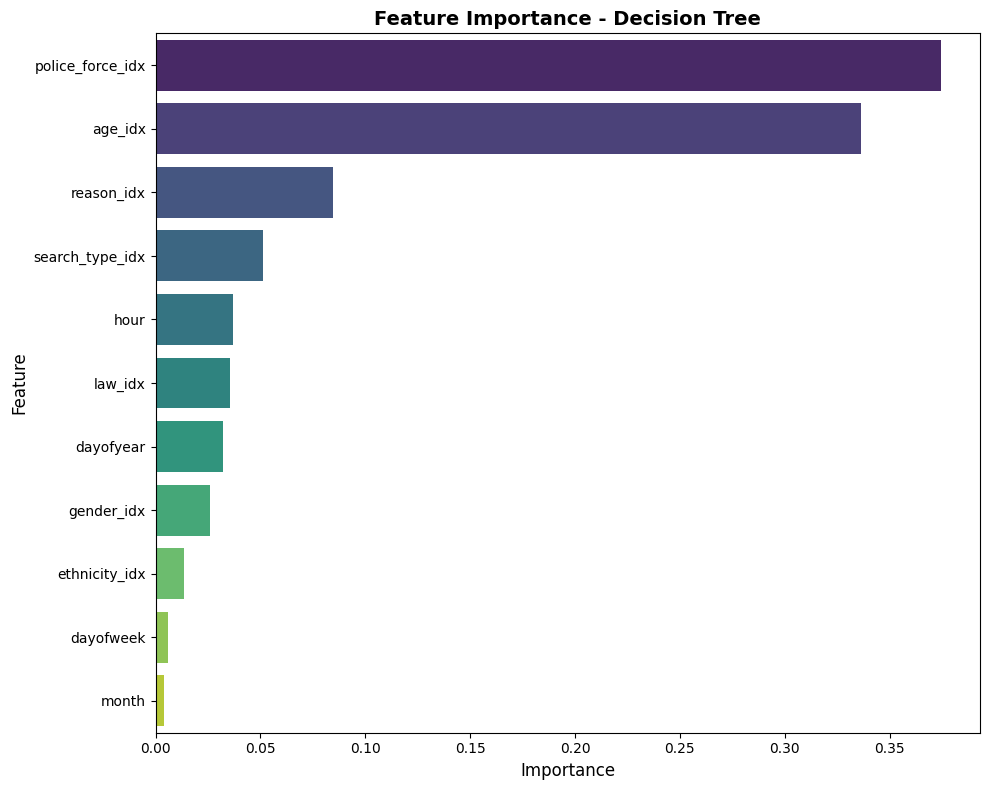


Total features: 11
Top feature: police_force_idx (0.3743)
Top 5 features account for: 88.32% of total importance

✓ Feature importance saved to 'feature_importance.csv'


Test data size: 99378
Class distribution (training): Neg=73.91%, Pos=26.09%



THRESHOLD-INDEPENDENT METRICS
AUC-ROC: 0.5750
AUC-PR : 0.3104



TRAINED MODEL METRICS (threshold=0.5)
Accuracy:           0.5572
Weighted Precision: 0.6938
Weighted Recall:    0.5572
Weighted F1 Score:  0.5804


/home/alumno/py313ml/.venv/lib/python3.13/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
                                                                                

...


  Class 0 (support=72665):


    Precision: 0.8228
    Recall:    0.5027
    F1-Score:  0.6241



  Class 1 (support=26713):
    Precision: 0.3428
    Recall:    0.7055
    F1-Score:  0.4614



NAIVE BASELINE MODEL


Random predictions with P(class=1)=26.09%
Accuracy:           0.6108
Weighted Precision: 0.6073
Weighted Recall:    0.6108
Weighted F1 Score:  0.6090


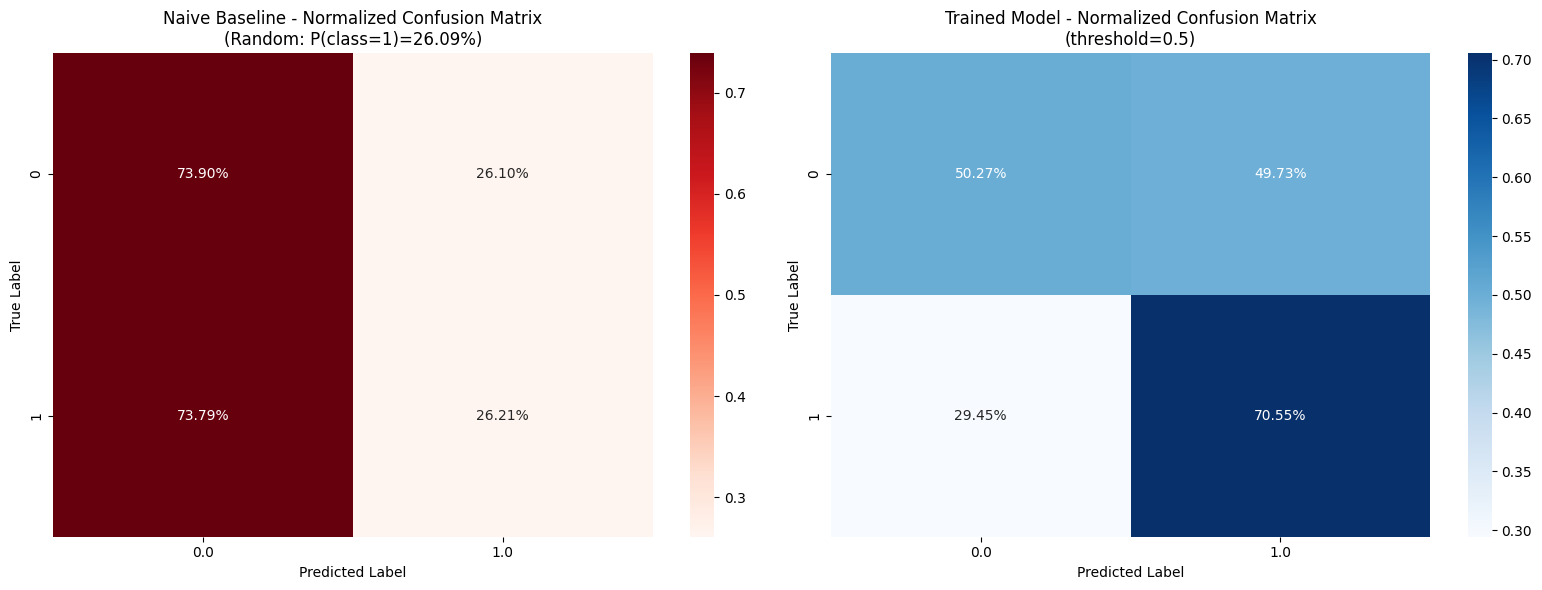


MODEL COMPARISON
Metric                 Trained      Baseline     Δ Improvement  
------------------------------------------------------------
Accuracy               0.5572       0.6108       -0.0535        
Weighted F1            0.5804       0.6090       -0.0286        
Weighted Precision     0.6938       0.6073       +0.0864        
Weighted Recall        0.5572       0.6108       -0.0535        
AUC-ROC                0.5750       ~0.5000      +0.0750        
*************** mult factor:  1 ***************
 Unbalance: 261,056 negatives vs 100,373 positives
   Ratio: 0.72 vs 0.28

Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 11.96 seconds.

                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
police_force_idx    0.384270
         age_idx    0.291083
      reason_idx    0.084926
      gender_idx    0.063210
 search_type_idx    0.047480
            hour    0.036229
         law_idx    0.035441
       dayofyear    0.032505
   ethnicity_idx    0.012904
       dayofweek    0.008946
           month    0.003005


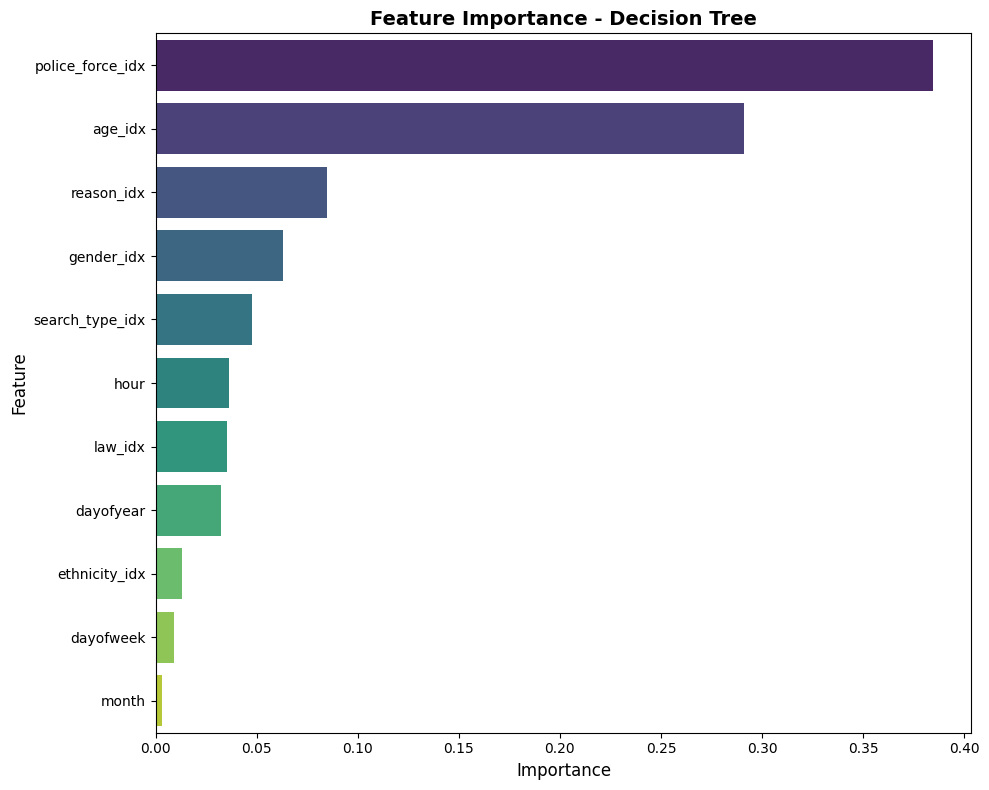


Total features: 11
Top feature: police_force_idx (0.3843)
Top 5 features account for: 87.10% of total importance

✓ Feature importance saved to 'feature_importance.csv'


Test data size: 80834
Class distribution (training): Neg=72.23%, Pos=27.77%



THRESHOLD-INDEPENDENT METRICS
AUC-ROC: 0.5722
AUC-PR : 0.3269



TRAINED MODEL METRICS (threshold=0.5)
Accuracy:           0.5691
Weighted Precision: 0.6845
Weighted Recall:    0.5691
Weighted F1 Score:  0.5885


/home/alumno/py313ml/.venv/lib/python3.13/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
                                                                                

...


  Class 0 (support=57716):


    Precision: 0.8115
    Recall:    0.5164
    F1-Score:  0.6312



  Class 1 (support=23118):
    Precision: 0.3672
    Recall:    0.7006
    F1-Score:  0.4819



NAIVE BASELINE MODEL


Random predictions with P(class=1)=27.77%
Accuracy:           0.5964
Weighted Precision: 0.5914
Weighted Recall:    0.5964
Weighted F1 Score:  0.5938


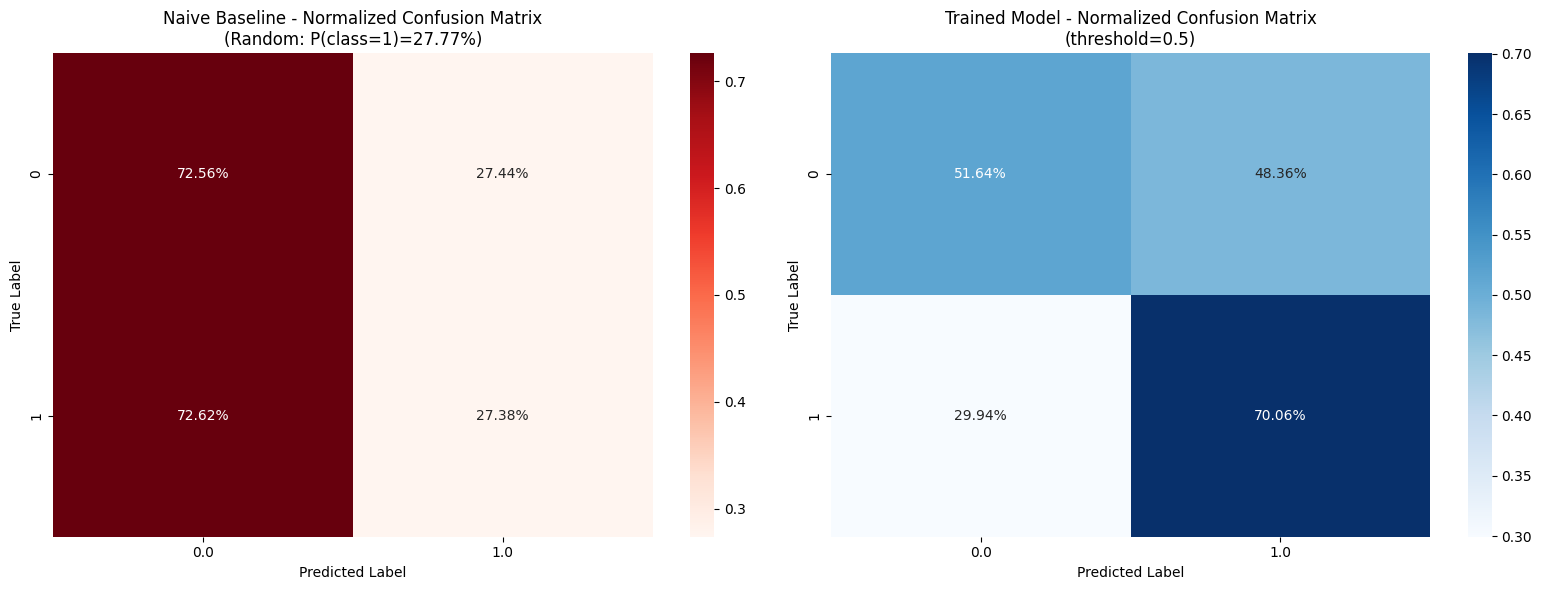


MODEL COMPARISON
Metric                 Trained      Baseline     Δ Improvement  
------------------------------------------------------------
Accuracy               0.5691       0.5964       -0.0273        
Weighted F1            0.5885       0.5938       -0.0053        
Weighted Precision     0.6845       0.5914       +0.0931        
Weighted Recall        0.5691       0.5964       -0.0273        
AUC-ROC                0.5722       ~0.5000      +0.0722        
*************** mult factor:  1 ***************
 Unbalance: 229,536 negatives vs 86,410 positives
   Ratio: 0.73 vs 0.27

Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 10.87 seconds.

                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
         law_idx    0.321066
         age_idx    0.268747
police_force_idx    0.227484
      reason_idx    0.066620
      gender_idx    0.042614
 search_type_idx    0.022091
            hour    0.018898
       dayofyear    0.017003
       dayofweek    0.006318
   ethnicity_idx    0.004862
           month    0.004299


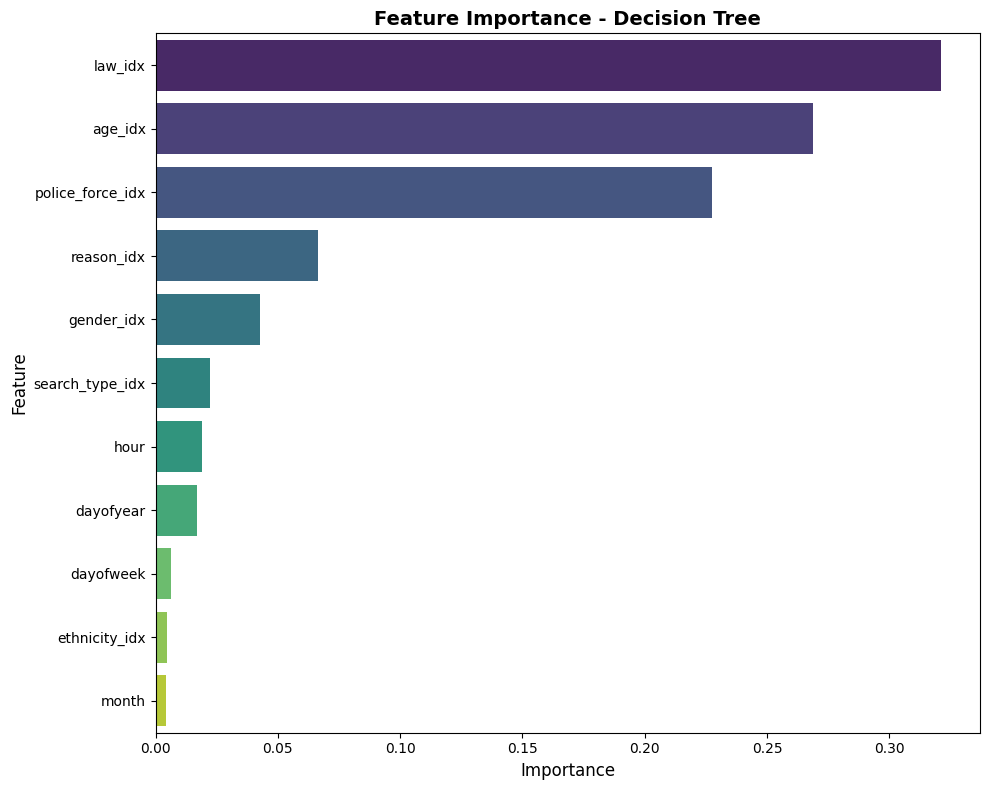


Total features: 11
Top feature: law_idx (0.3211)
Top 5 features account for: 92.65% of total importance

✓ Feature importance saved to 'feature_importance.csv'


Test data size: 71375
Class distribution (training): Neg=72.65%, Pos=27.35%



THRESHOLD-INDEPENDENT METRICS
AUC-ROC: 0.6399
AUC-PR : 0.3758



TRAINED MODEL METRICS (threshold=0.5)
Accuracy:           0.5754
Weighted Precision: 0.7187
Weighted Recall:    0.5754
Weighted F1 Score:  0.5933


/home/alumno/py313ml/.venv/lib/python3.13/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
                                                                                

...


  Class 0 (support=51324):


    Precision: 0.8523
    Recall:    0.4954
    F1-Score:  0.6266



  Class 1 (support=20051):
    Precision: 0.3766
    Recall:    0.7803
    F1-Score:  0.5080



NAIVE BASELINE MODEL


Random predictions with P(class=1)=27.35%
Accuracy:           0.5995
Weighted Precision: 0.5961
Weighted Recall:    0.5995
Weighted F1 Score:  0.5978


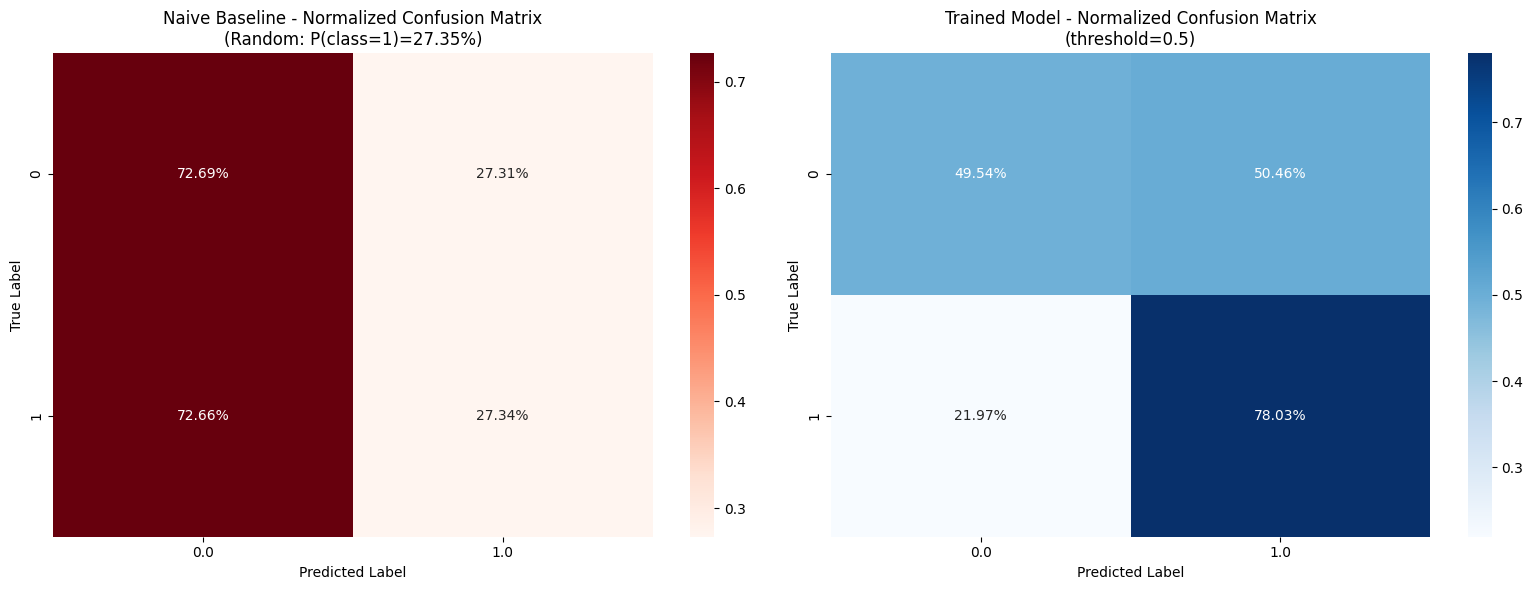


MODEL COMPARISON
Metric                 Trained      Baseline     Δ Improvement  
------------------------------------------------------------
Accuracy               0.5754       0.5995       -0.0241        
Weighted F1            0.5933       0.5978       -0.0045        
Weighted Precision     0.7187       0.5961       +0.1225        
Weighted Recall        0.5754       0.5995       -0.0241        
AUC-ROC                0.6399       ~0.5000      +0.1399        


In [15]:
fractions = {
    2022: 0.8,
    2023: 0.8,
    2024: 0.8,
    2025: 0.8
}

# Muestreo estratificado
train_df = df_final.sampleBy("year", fractions, seed=42)

# El test set son los registros que NO están en train
test_df = df_final.join(train_df, on=df_final.columns, how="left_anti")

for year in [2023, 2024, 2025]:
    if year == 2023:
        train_df_objective = (
            train_df.filter(
                F.col("year") <= year
            )
        )
        
        test_df_objective = (
            test_df.filter(
                F.col("year") <= year
            )
        )
    else:
        train_df_objective = (
            train_df.filter(
                F.col("year") == year
            )
        )
        
        test_df_objective = (
            test_df.filter(
                F.col("year") == year
            )
        )

    mult = 1
    print("*"*15, "mult factor: ", mult, "*"*15)
    trained_pipeline, neg_count, pos_count = train_dt(
        train_df_objective,
        categorical_cols, 
        numeric_cols,
        feature_cols,
        normalized_weights=True,
        weight_multiplier = mult,
        model = "DT"
    )

    trained_model = trained_pipeline.stages[-1]
    
    show_importances(
        trained_model,
        categorical_cols,
        numeric_cols,
        feature_cols
    )

    # for thres in np.arange(0.7, 0.8, 0.03):
    calculate_metrics(
        trained_pipeline,
        test_df_objective,
        neg_count,
        pos_count,
        threshold = 0.5
    )

### Random Forest

*************** mult factor:  1 ***************
 Unbalance: 329,459 negatives vs 116,293 positives
   Ratio: 0.74 vs 0.26

Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 14.67 seconds.

                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
         age_idx    0.365455
police_force_idx    0.222731
 search_type_idx    0.097270
      reason_idx    0.088197
         law_idx    0.068387
            hour    0.047862
      gender_idx    0.030128
       dayofyear    0.027886
   ethnicity_idx    0.027544
           month    0.012939
       dayofweek    0.011599


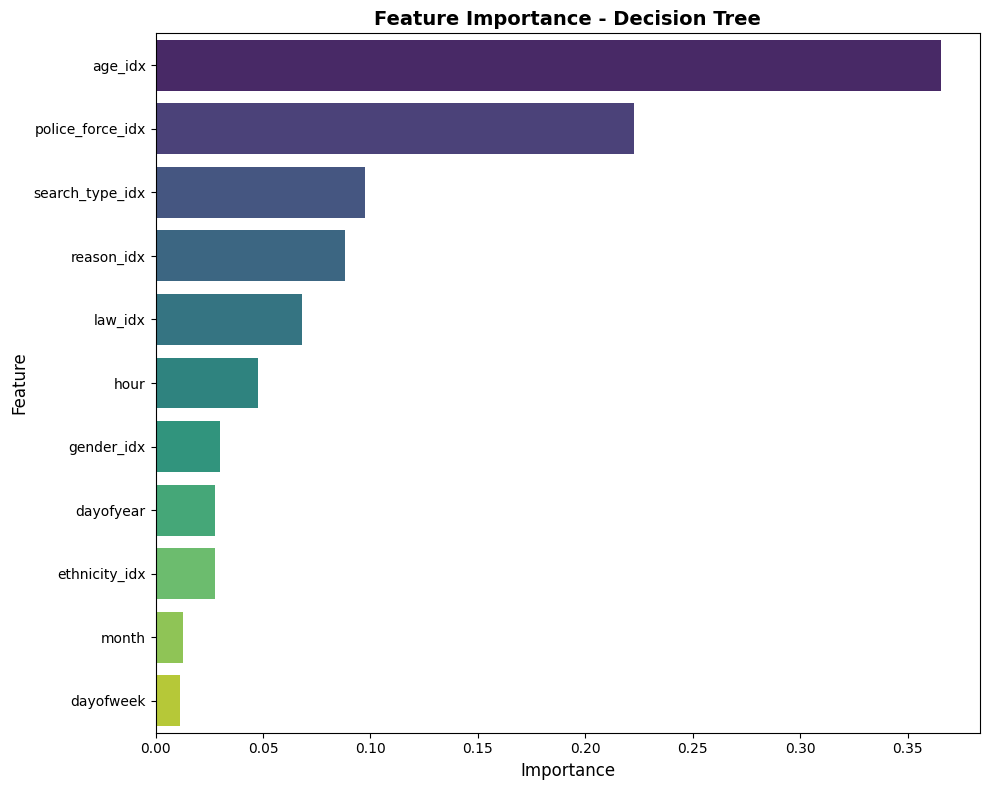


Total features: 11
Top feature: age_idx (0.3655)
Top 5 features account for: 84.20% of total importance

✓ Feature importance saved to 'feature_importance.csv'


Test data size: 99378
Class distribution (training): Neg=73.91%, Pos=26.09%



THRESHOLD-INDEPENDENT METRICS
AUC-ROC: 0.6455
AUC-PR : 0.3749



TRAINED MODEL METRICS (threshold=0.5)
Accuracy:           0.5800
Weighted Precision: 0.6875
Weighted Recall:    0.5800
Weighted F1 Score:  0.6038


/home/alumno/py313ml/.venv/lib/python3.13/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
                                                                                

...


  Class 0 (support=72665):


    Precision: 0.8119
    Recall:    0.5540
    F1-Score:  0.6586



  Class 1 (support=26713):
    Precision: 0.3492
    Recall:    0.6508
    F1-Score:  0.4545



NAIVE BASELINE MODEL


Random predictions with P(class=1)=26.09%
Accuracy:           0.6108
Weighted Precision: 0.6067
Weighted Recall:    0.6108
Weighted F1 Score:  0.6087


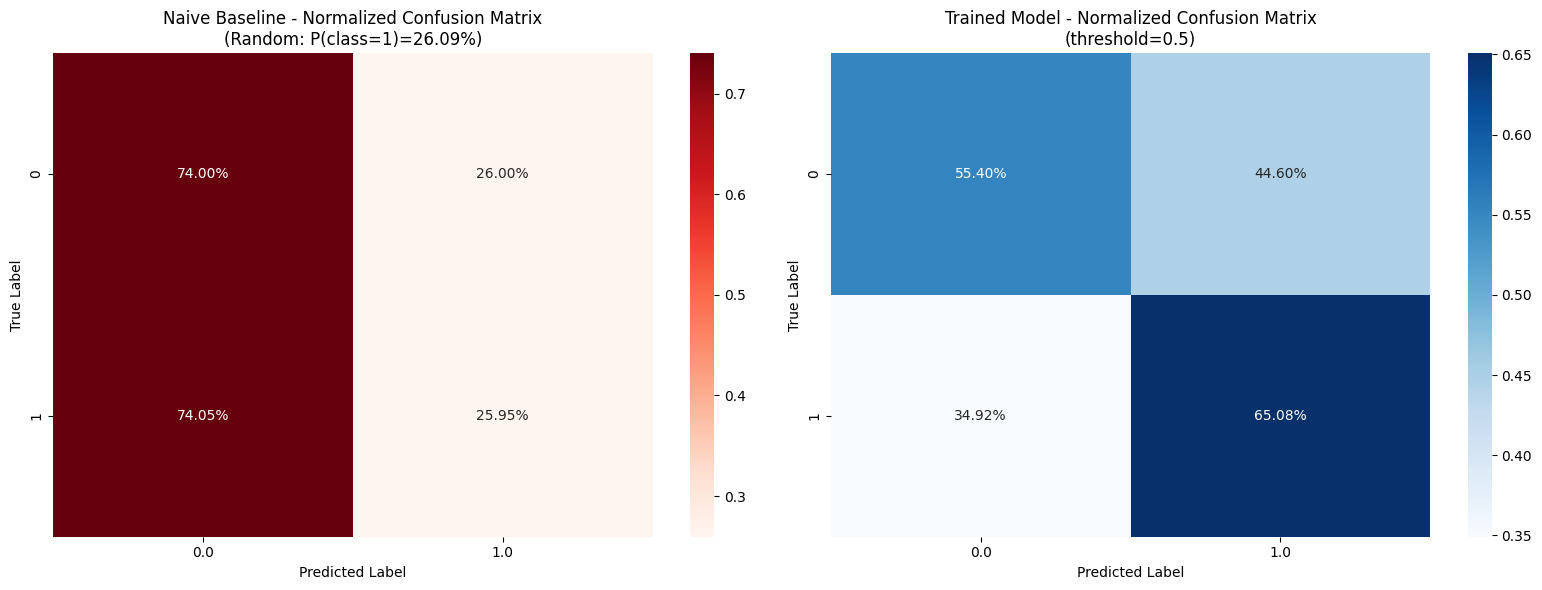


MODEL COMPARISON
Metric                 Trained      Baseline     Δ Improvement  
------------------------------------------------------------
Accuracy               0.5800       0.6108       -0.0308        
Weighted F1            0.6038       0.6087       -0.0050        
Weighted Precision     0.6875       0.6067       +0.0808        
Weighted Recall        0.5800       0.6108       -0.0308        
AUC-ROC                0.6455       ~0.5000      +0.1455        
*************** mult factor:  1 ***************
 Unbalance: 261,056 negatives vs 100,373 positives
   Ratio: 0.72 vs 0.28

Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 16.21 seconds.

                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
         age_idx    0.341615
police_force_idx    0.233371
      reason_idx    0.113677
 search_type_idx    0.073055
      gender_idx    0.054985
         law_idx    0.051254
            hour    0.039548
   ethnicity_idx    0.036211
       dayofyear    0.035423
           month    0.010737
       dayofweek    0.010123


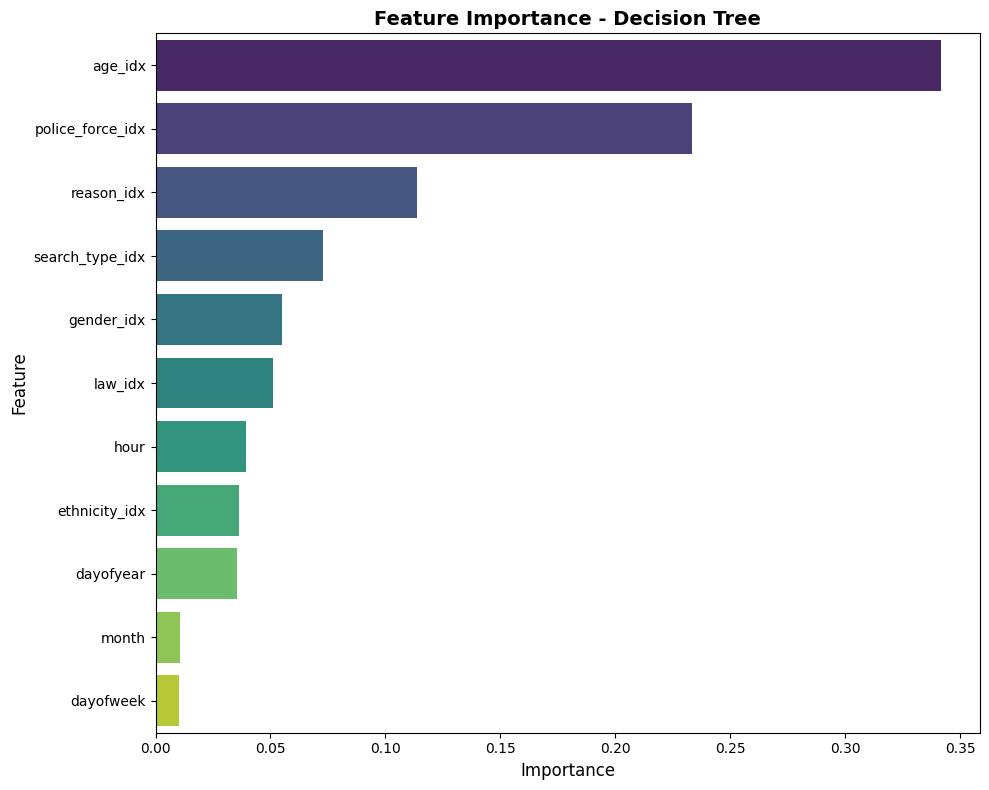


Total features: 11
Top feature: age_idx (0.3416)
Top 5 features account for: 81.67% of total importance

✓ Feature importance saved to 'feature_importance.csv'


Test data size: 80834
Class distribution (training): Neg=72.23%, Pos=27.77%



THRESHOLD-INDEPENDENT METRICS
AUC-ROC: 0.6523
AUC-PR : 0.4060



TRAINED MODEL METRICS (threshold=0.5)
Accuracy:           0.5920
Weighted Precision: 0.6807
Weighted Recall:    0.5920
Weighted F1 Score:  0.6117


/home/alumno/py313ml/.venv/lib/python3.13/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
                                                                                

...


  Class 0 (support=57716):


    Precision: 0.8025
    Recall:    0.5686
    F1-Score:  0.6656



  Class 1 (support=23118):
    Precision: 0.3766
    Recall:    0.6506
    F1-Score:  0.4770



NAIVE BASELINE MODEL


Random predictions with P(class=1)=27.77%
Accuracy:           0.5965
Weighted Precision: 0.5936
Weighted Recall:    0.5965
Weighted F1 Score:  0.5950


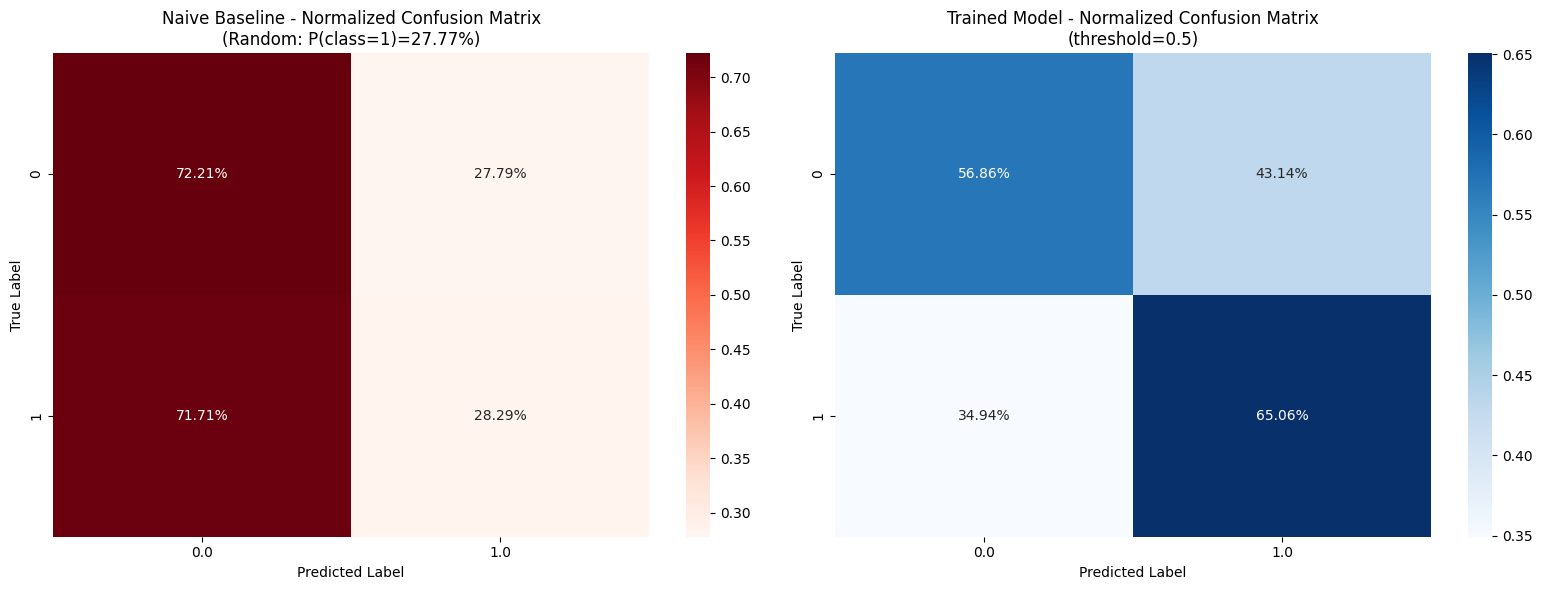


MODEL COMPARISON
Metric                 Trained      Baseline     Δ Improvement  
------------------------------------------------------------
Accuracy               0.5920       0.5965       -0.0044        
Weighted F1            0.6117       0.5950       +0.0166        
Weighted Precision     0.6807       0.5936       +0.0870        
Weighted Recall        0.5920       0.5965       -0.0044        
AUC-ROC                0.6523       ~0.5000      +0.1523        
*************** mult factor:  1 ***************
 Unbalance: 229,536 negatives vs 86,410 positives
   Ratio: 0.73 vs 0.27

Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 15.22 seconds.

                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
         age_idx    0.271360
         law_idx    0.267669
police_force_idx    0.189608
      reason_idx    0.133223
      gender_idx    0.034629
            hour    0.025100
 search_type_idx    0.023972
       dayofyear    0.022740
   ethnicity_idx    0.012506
           month    0.011252
       dayofweek    0.007938


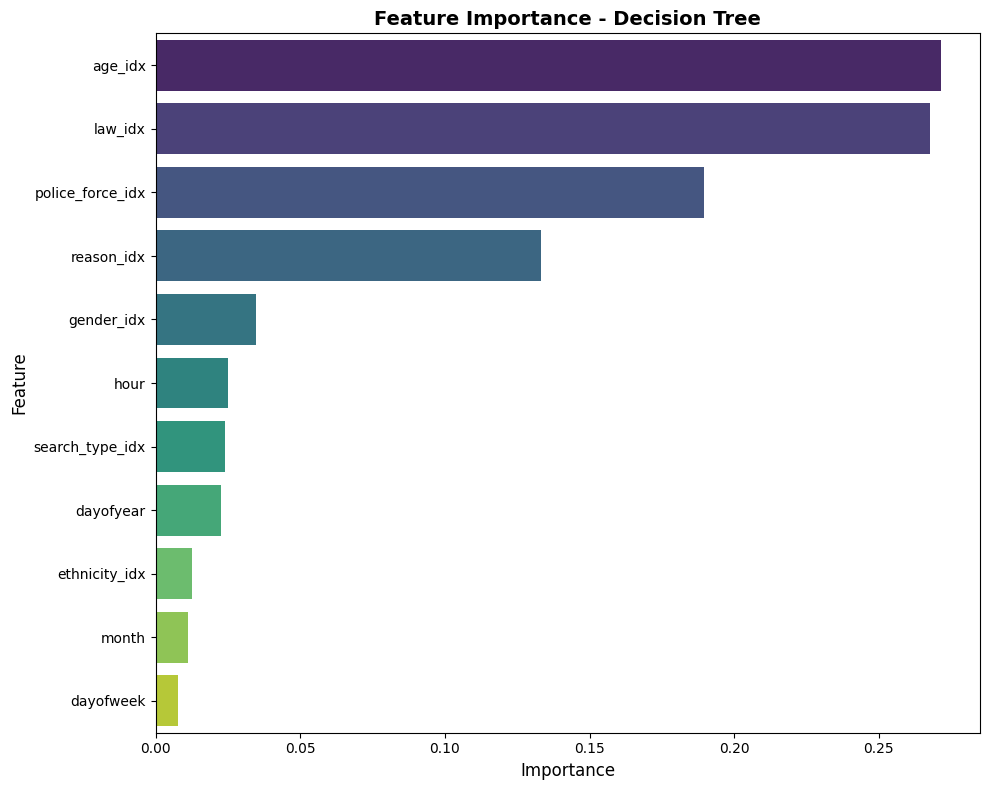


Total features: 11
Top feature: age_idx (0.2714)
Top 5 features account for: 89.65% of total importance

✓ Feature importance saved to 'feature_importance.csv'


Test data size: 71375
Class distribution (training): Neg=72.65%, Pos=27.35%



THRESHOLD-INDEPENDENT METRICS
AUC-ROC: 0.6973
AUC-PR : 0.4328



TRAINED MODEL METRICS (threshold=0.5)
Accuracy:           0.5793
Weighted Precision: 0.7197
Weighted Recall:    0.5793
Weighted F1 Score:  0.5974


/home/alumno/py313ml/.venv/lib/python3.13/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
                                                                                

...


  Class 0 (support=51324):


    Precision: 0.8529
    Recall:    0.5015
    F1-Score:  0.6316



  Class 1 (support=20051):
    Precision: 0.3789
    Recall:    0.7786
    F1-Score:  0.5098



NAIVE BASELINE MODEL


Random predictions with P(class=1)=27.35%
Accuracy:           0.5982
Weighted Precision: 0.5963
Weighted Recall:    0.5982
Weighted F1 Score:  0.5972


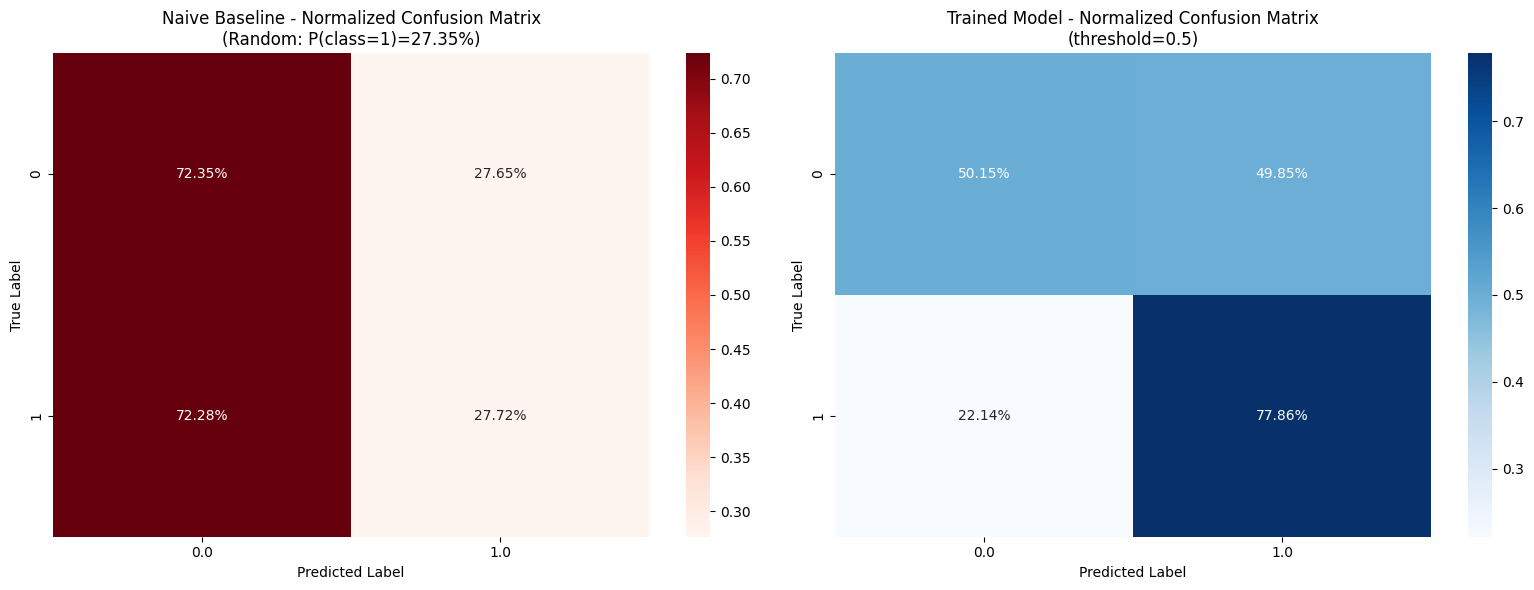


MODEL COMPARISON
Metric                 Trained      Baseline     Δ Improvement  
------------------------------------------------------------
Accuracy               0.5793       0.5982       -0.0188        
Weighted F1            0.5974       0.5972       +0.0001        
Weighted Precision     0.7197       0.5963       +0.1234        
Weighted Recall        0.5793       0.5982       -0.0188        
AUC-ROC                0.6973       ~0.5000      +0.1973        


In [16]:
fractions = {
    2022: 0.8,
    2023: 0.8,
    2024: 0.8,
    2025: 0.8
}

# Muestreo estratificado
train_df = df_final.sampleBy("year", fractions, seed=42)

# El test set son los registros que NO están en train
test_df = df_final.join(train_df, on=df_final.columns, how="left_anti")

for year in [2023, 2024, 2025]:
    if year == 2023:
        train_df_objective = (
            train_df.filter(
                F.col("year") <= year
            )
        )
        
        test_df_objective = (
            test_df.filter(
                F.col("year") <= year
            )
        )
    else:
        train_df_objective = (
            train_df.filter(
                F.col("year") == year
            )
        )
        
        test_df_objective = (
            test_df.filter(
                F.col("year") == year
            )
        )

    mult = 1
    print("*"*15, "mult factor: ", mult, "*"*15)
    trained_pipeline, neg_count, pos_count = train_dt(
        train_df_objective,
        categorical_cols, 
        numeric_cols,
        feature_cols,
        normalized_weights=True,
        weight_multiplier = mult,
        model = "RF"
    )

    trained_model = trained_pipeline.stages[-1]
    
    show_importances(
        trained_model,
        categorical_cols,
        numeric_cols,
        feature_cols
    )

    # for thres in np.arange(0.7, 0.8, 0.03):
    calculate_metrics(
        trained_pipeline,
        test_df_objective,
        neg_count,
        pos_count,
        threshold = 0.5
    )

## Threshold 0.535

### Decision Tree

*************** mult factor:  1 ***************
 Unbalance: 329,459 negatives vs 116,293 positives
   Ratio: 0.74 vs 0.26

Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 14.79 seconds.

                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
         age_idx    0.365455
police_force_idx    0.222731
 search_type_idx    0.097270
      reason_idx    0.088197
         law_idx    0.068387
            hour    0.047862
      gender_idx    0.030128
       dayofyear    0.027886
   ethnicity_idx    0.027544
           month    0.012939
       dayofweek    0.011599


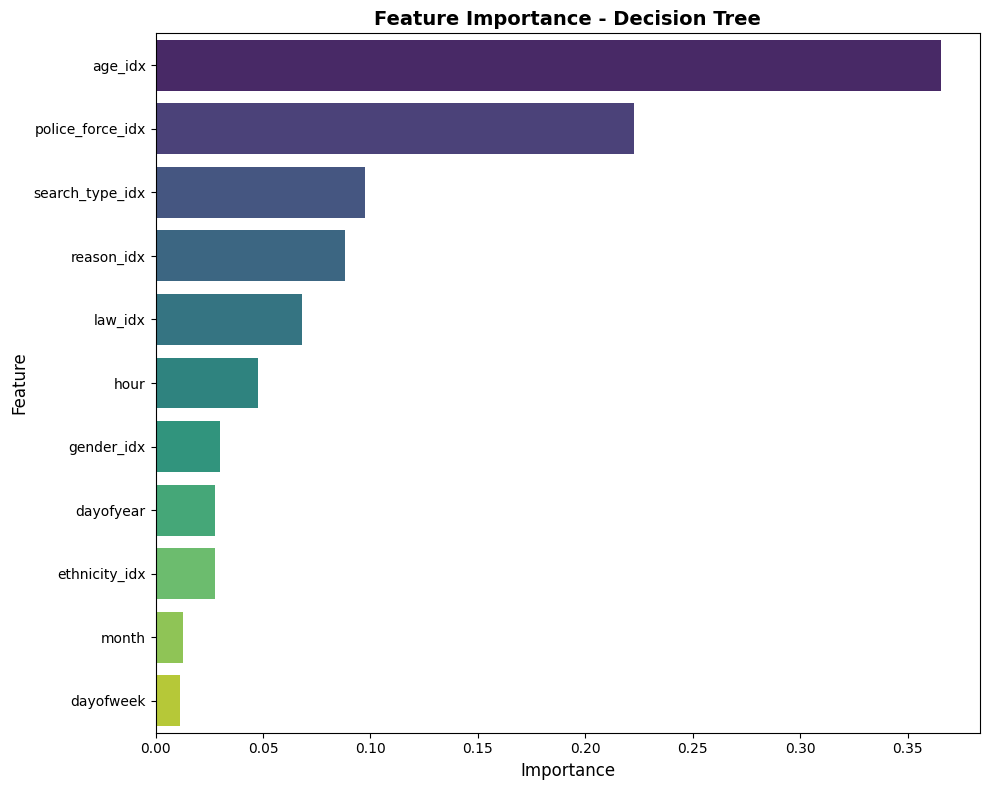


Total features: 11
Top feature: age_idx (0.3655)
Top 5 features account for: 84.20% of total importance

✓ Feature importance saved to 'feature_importance.csv'


Test data size: 99378
Class distribution (training): Neg=73.91%, Pos=26.09%



THRESHOLD-INDEPENDENT METRICS
AUC-ROC: 0.6455
AUC-PR : 0.3749



TRAINED MODEL METRICS (threshold=0.535)
Accuracy:           0.6313
Weighted Precision: 0.6784
Weighted Recall:    0.6313
Weighted F1 Score:  0.6477


/home/alumno/py313ml/.venv/lib/python3.13/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
                                                                                

...


  Class 0 (support=72665):


    Precision: 0.7924
    Recall:    0.6718
    F1-Score:  0.7271



  Class 1 (support=26713):
    Precision: 0.3685
    Recall:    0.5211
    F1-Score:  0.4318



NAIVE BASELINE MODEL


Random predictions with P(class=1)=26.09%
Accuracy:           0.6122
Weighted Precision: 0.6081
Weighted Recall:    0.6122
Weighted F1 Score:  0.6101


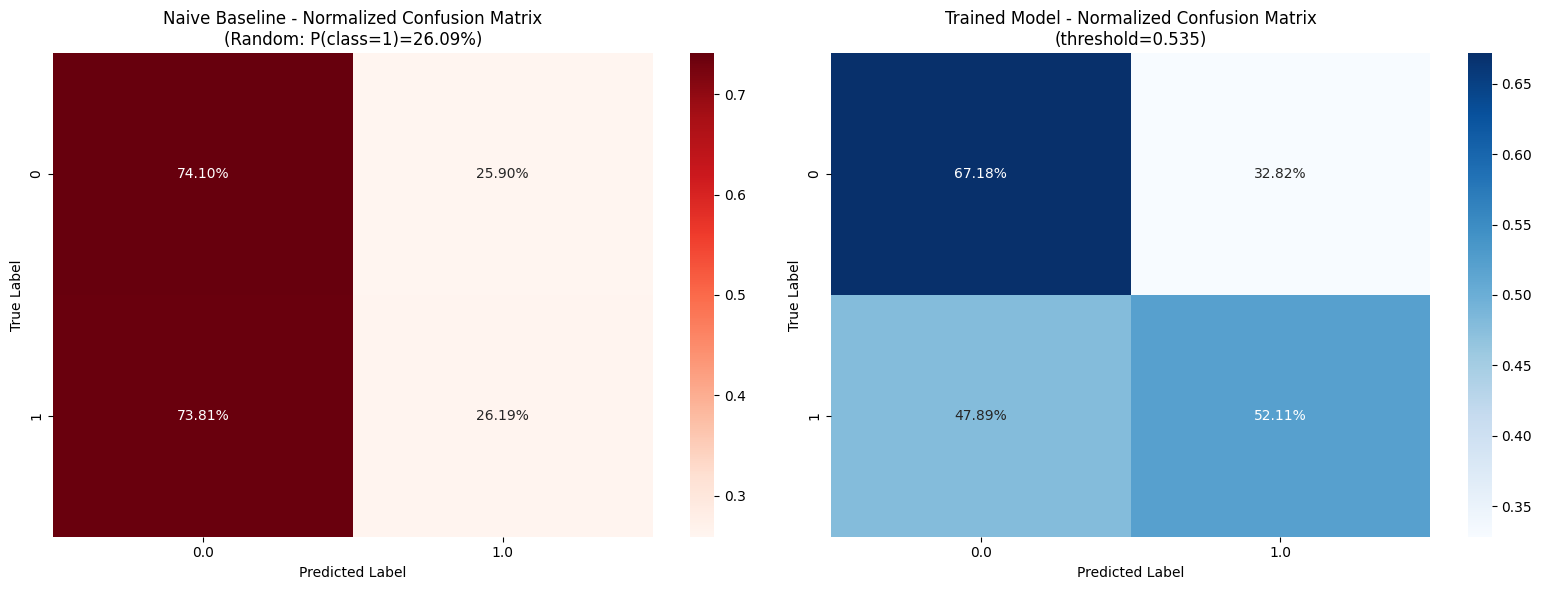


MODEL COMPARISON
Metric                 Trained      Baseline     Δ Improvement  
------------------------------------------------------------
Accuracy               0.6313       0.6122       +0.0190        
Weighted F1            0.6477       0.6101       +0.0376        
Weighted Precision     0.6784       0.6081       +0.0704        
Weighted Recall        0.6313       0.6122       +0.0190        
AUC-ROC                0.6455       ~0.5000      +0.1455        
*************** mult factor:  1 ***************


 Unbalance: 261,056 negatives vs 100,373 positives
   Ratio: 0.72 vs 0.28

Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 16.23 seconds.

                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
         age_idx    0.341615
police_force_idx    0.233371
      reason_idx    0.113677
 search_type_idx    0.073055
      gender_idx    0.054985
         law_idx    0.051254
            hour    0.039548
   ethnicity_idx    0.036211
       dayofyear    0.035423
           month    0.010737
       dayofweek    0.010123


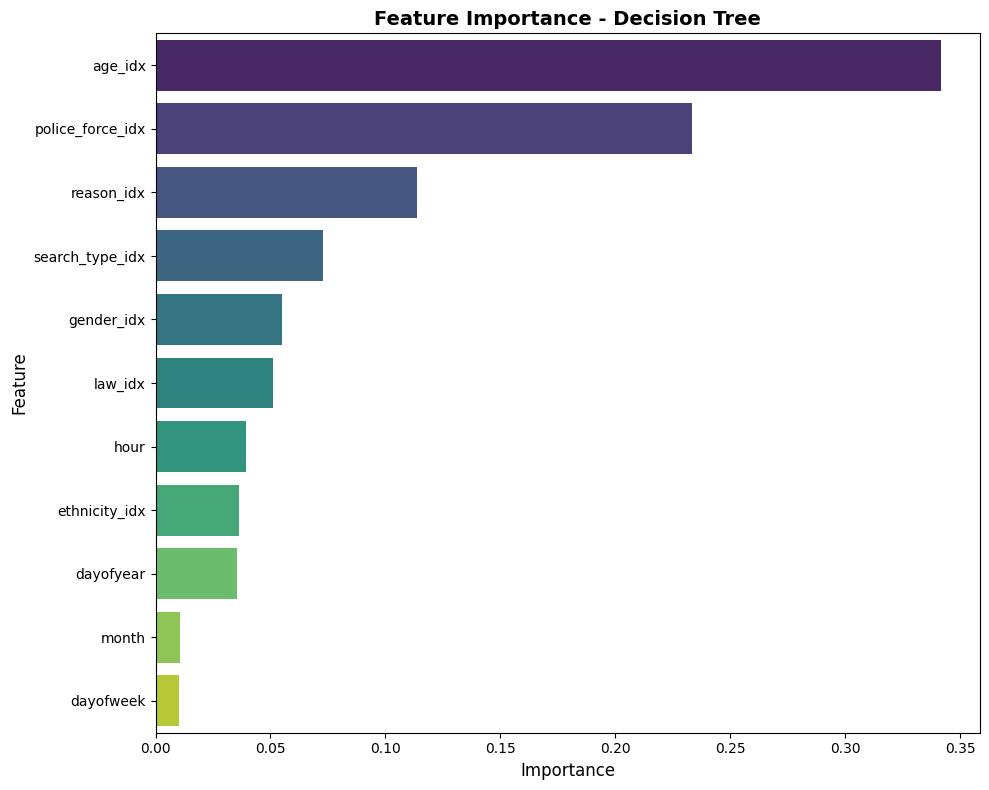


Total features: 11
Top feature: age_idx (0.3416)
Top 5 features account for: 81.67% of total importance

✓ Feature importance saved to 'feature_importance.csv'


Test data size: 80834
Class distribution (training): Neg=72.23%, Pos=27.77%



THRESHOLD-INDEPENDENT METRICS
AUC-ROC: 0.6523
AUC-PR : 0.4060



TRAINED MODEL METRICS (threshold=0.535)
Accuracy:           0.6312
Weighted Precision: 0.6732
Weighted Recall:    0.6312
Weighted F1 Score:  0.6454


/home/alumno/py313ml/.venv/lib/python3.13/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
                                                                                

...


  Class 0 (support=57716):


    Precision: 0.7847
    Recall:    0.6664
    F1-Score:  0.7207



  Class 1 (support=23118):
    Precision: 0.3949
    Recall:    0.5436
    F1-Score:  0.4574



NAIVE BASELINE MODEL


Random predictions with P(class=1)=27.77%
Accuracy:           0.5939
Weighted Precision: 0.5920
Weighted Recall:    0.5939
Weighted F1 Score:  0.5930


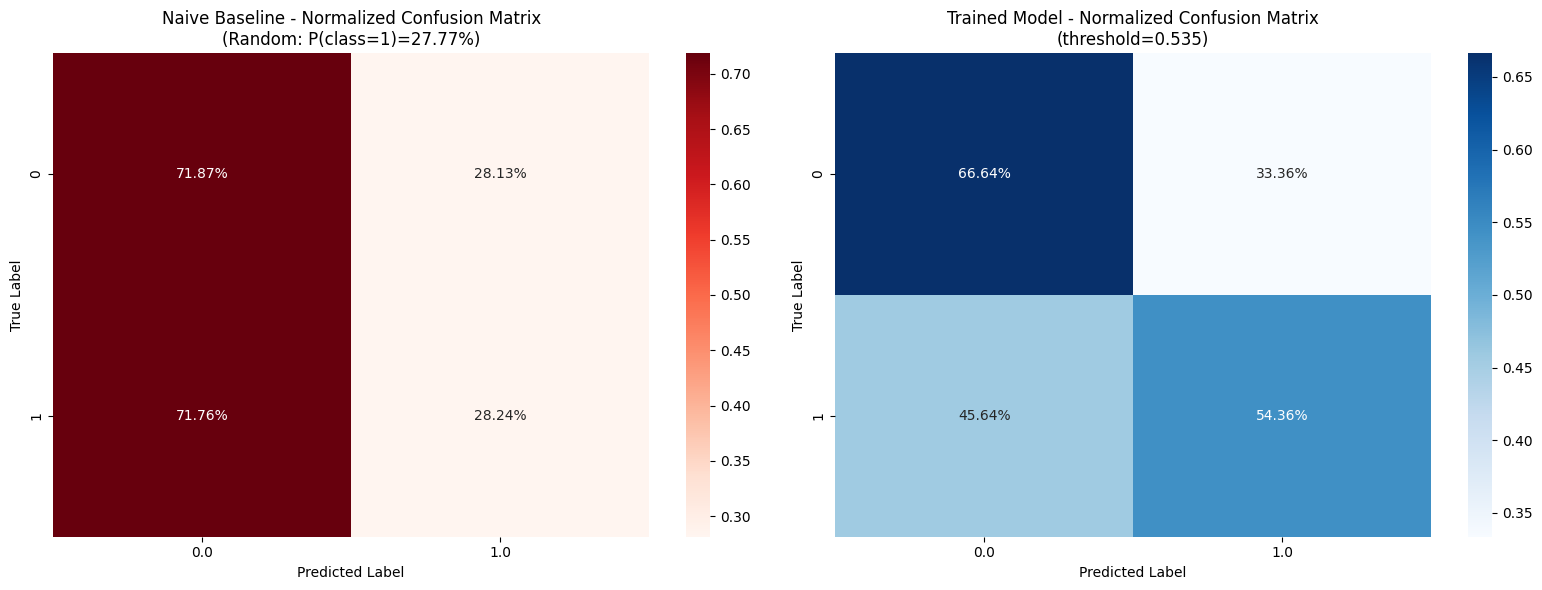


MODEL COMPARISON
Metric                 Trained      Baseline     Δ Improvement  
------------------------------------------------------------
Accuracy               0.6312       0.5939       +0.0373        
Weighted F1            0.6454       0.5930       +0.0525        
Weighted Precision     0.6732       0.5920       +0.0812        
Weighted Recall        0.6312       0.5939       +0.0373        
AUC-ROC                0.6523       ~0.5000      +0.1523        
*************** mult factor:  1 ***************
 Unbalance: 229,536 negatives vs 86,410 positives
   Ratio: 0.73 vs 0.27

Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 15.26 seconds.

                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
         age_idx    0.271360
         law_idx    0.267669
police_force_idx    0.189608
      reason_idx    0.133223
      gender_idx    0.034629
            hour    0.025100
 search_type_idx    0.023972
       dayofyear    0.022740
   ethnicity_idx    0.012506
           month    0.011252
       dayofweek    0.007938


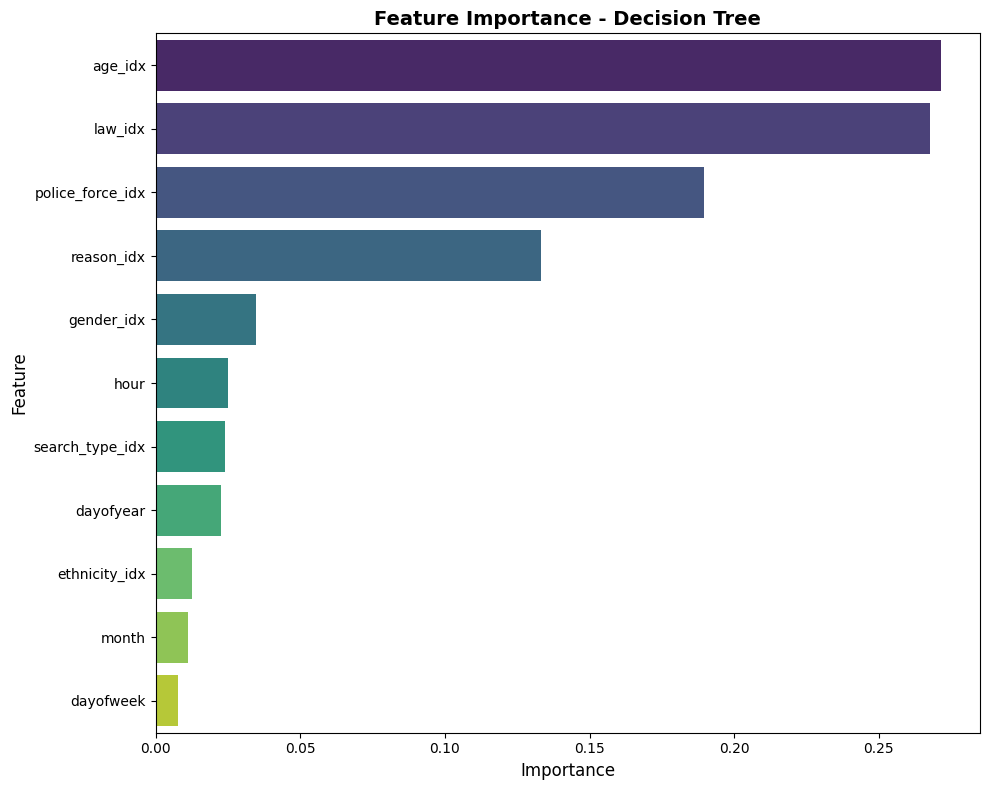


Total features: 11
Top feature: age_idx (0.2714)
Top 5 features account for: 89.65% of total importance

✓ Feature importance saved to 'feature_importance.csv'


Test data size: 71375
Class distribution (training): Neg=72.65%, Pos=27.35%



THRESHOLD-INDEPENDENT METRICS
AUC-ROC: 0.6973
AUC-PR : 0.4328



TRAINED MODEL METRICS (threshold=0.535)
Accuracy:           0.6166
Weighted Precision: 0.7084
Weighted Recall:    0.6166
Weighted F1 Score:  0.6360


/home/alumno/py313ml/.venv/lib/python3.13/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
                                                                                

...


  Class 0 (support=51324):


    Precision: 0.8305
    Recall:    0.5865
    F1-Score:  0.6875



  Class 1 (support=20051):
    Precision: 0.3959
    Recall:    0.6936
    F1-Score:  0.5041



NAIVE BASELINE MODEL


Random predictions with P(class=1)=27.35%
Accuracy:           0.5972
Weighted Precision: 0.5935
Weighted Recall:    0.5972
Weighted F1 Score:  0.5953


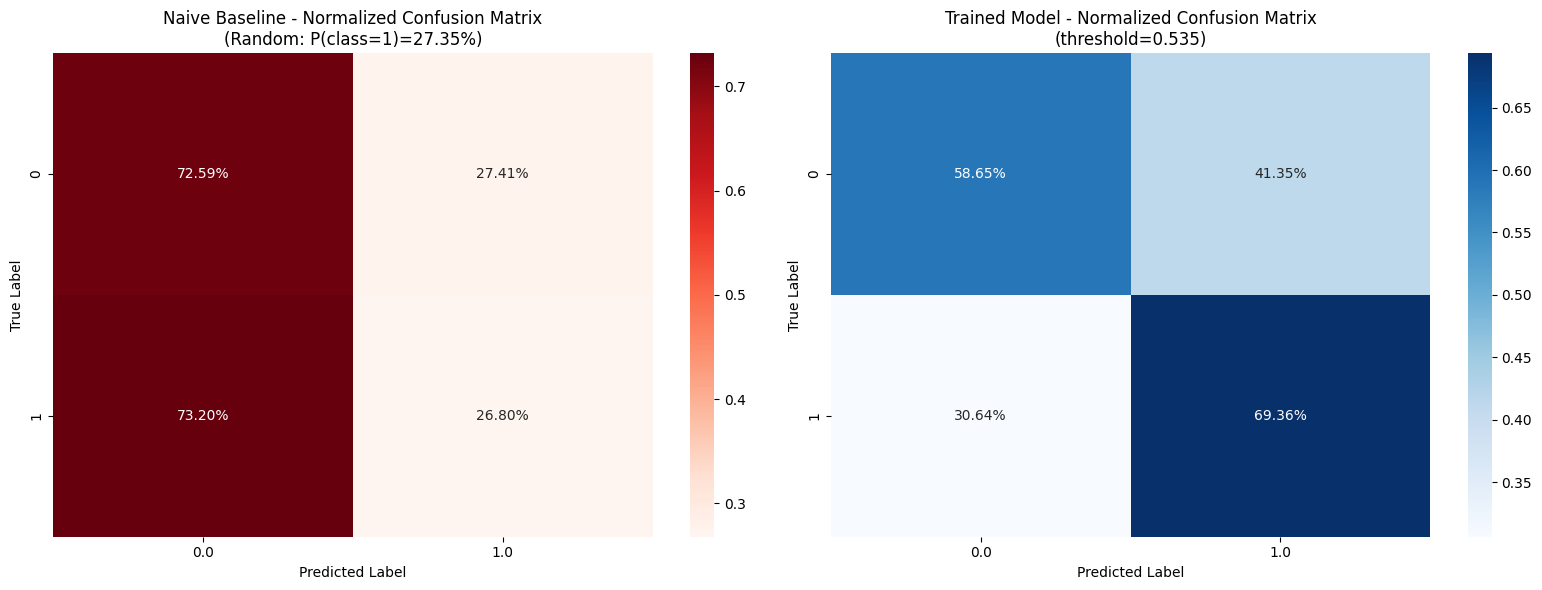


MODEL COMPARISON
Metric                 Trained      Baseline     Δ Improvement  
------------------------------------------------------------
Accuracy               0.6166       0.5972       +0.0194        
Weighted F1            0.6360       0.5953       +0.0406        
Weighted Precision     0.7084       0.5935       +0.1149        
Weighted Recall        0.6166       0.5972       +0.0194        
AUC-ROC                0.6973       ~0.5000      +0.1973        


In [17]:
fractions = {
    2022: 0.8,
    2023: 0.8,
    2024: 0.8,
    2025: 0.8
}

# Muestreo estratificado
train_df = df_final.sampleBy("year", fractions, seed=42)

# El test set son los registros que NO están en train
test_df = df_final.join(train_df, on=df_final.columns, how="left_anti")

for year in [2023, 2024, 2025]:
    if year == 2023:
        train_df_objective = (
            train_df.filter(
                F.col("year") <= year
            )
        )
        
        test_df_objective = (
            test_df.filter(
                F.col("year") <= year
            )
        )
    else:
        train_df_objective = (
            train_df.filter(
                F.col("year") == year
            )
        )
        
        test_df_objective = (
            test_df.filter(
                F.col("year") == year
            )
        )

    mult = 1
    print("*"*15, "mult factor: ", mult, "*"*15)
    trained_pipeline, neg_count, pos_count = train_dt(
        train_df_objective,
        categorical_cols, 
        numeric_cols,
        feature_cols,
        normalized_weights=True,
        weight_multiplier = mult,
        model = "RF"
    )

    trained_model = trained_pipeline.stages[-1]
    
    show_importances(
        trained_model,
        categorical_cols,
        numeric_cols,
        feature_cols
    )

    # for thres in np.arange(0.7, 0.8, 0.03):
    calculate_metrics(
        trained_pipeline,
        test_df_objective,
        neg_count,
        pos_count,
        threshold = 0.535
    )

### Random Forest

*************** mult factor:  1 ***************
 Unbalance: 329,459 negatives vs 116,293 positives
   Ratio: 0.74 vs 0.26

Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 14.22 seconds.

                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
         age_idx    0.365455
police_force_idx    0.222731
 search_type_idx    0.097270
      reason_idx    0.088197
         law_idx    0.068387
            hour    0.047862
      gender_idx    0.030128
       dayofyear    0.027886
   ethnicity_idx    0.027544
           month    0.012939
       dayofweek    0.011599


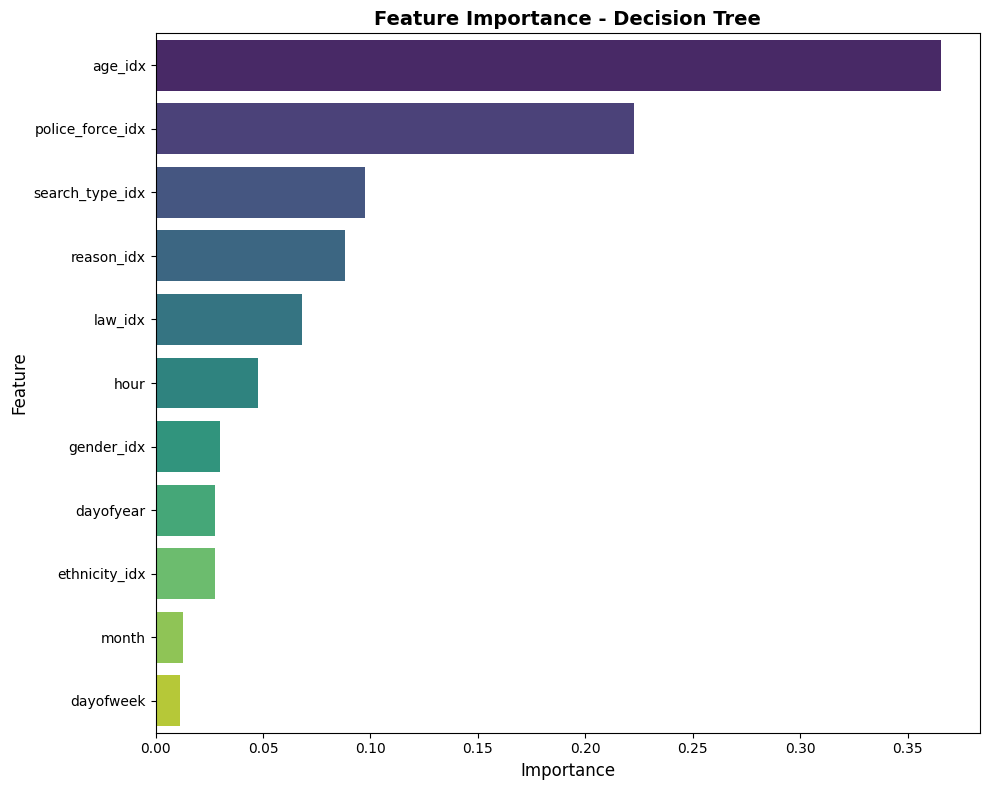


Total features: 11
Top feature: age_idx (0.3655)
Top 5 features account for: 84.20% of total importance

✓ Feature importance saved to 'feature_importance.csv'


Test data size: 99378
Class distribution (training): Neg=73.91%, Pos=26.09%



THRESHOLD-INDEPENDENT METRICS
AUC-ROC: 0.6455
AUC-PR : 0.3749



TRAINED MODEL METRICS (threshold=0.535)
Accuracy:           0.6313
Weighted Precision: 0.6784
Weighted Recall:    0.6313
Weighted F1 Score:  0.6477


/home/alumno/py313ml/.venv/lib/python3.13/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
                                                                                

...


  Class 0 (support=72665):


    Precision: 0.7924
    Recall:    0.6718
    F1-Score:  0.7271



  Class 1 (support=26713):
    Precision: 0.3685
    Recall:    0.5211
    F1-Score:  0.4318



NAIVE BASELINE MODEL


Random predictions with P(class=1)=26.09%
Accuracy:           0.6104
Weighted Precision: 0.6069
Weighted Recall:    0.6104
Weighted F1 Score:  0.6086


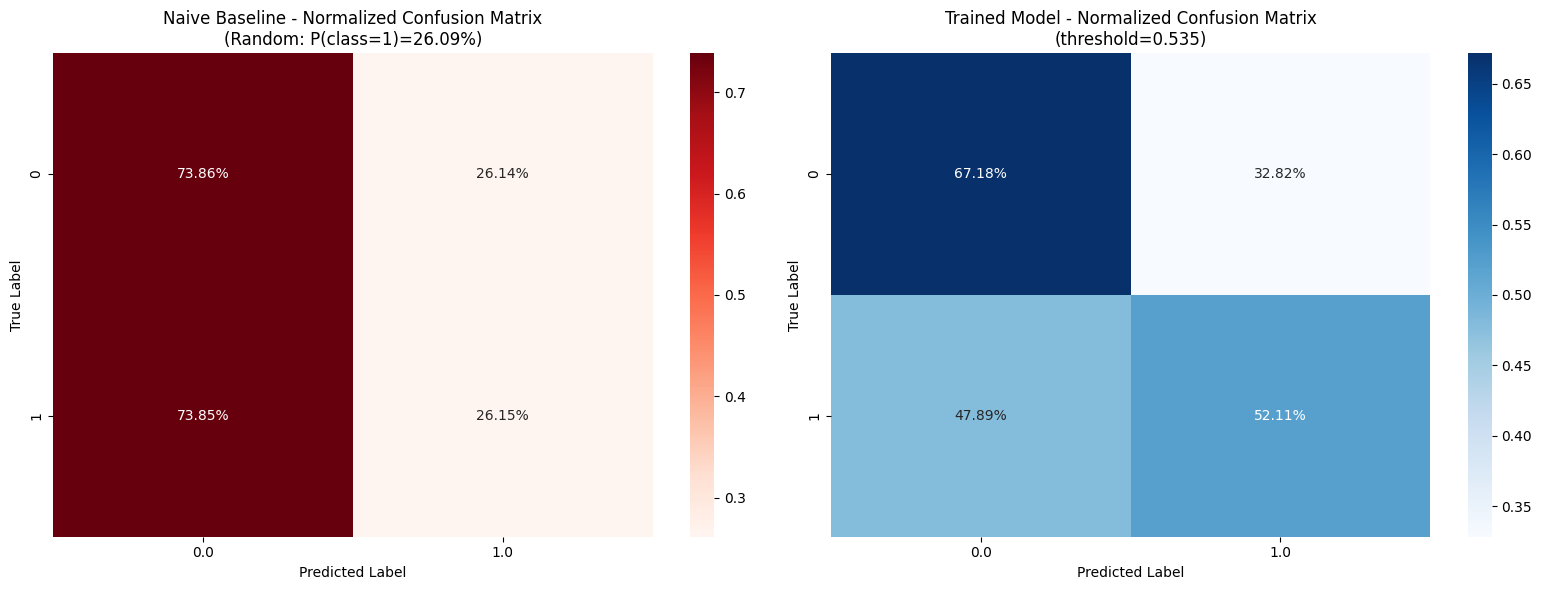


MODEL COMPARISON
Metric                 Trained      Baseline     Δ Improvement  
------------------------------------------------------------
Accuracy               0.6313       0.6104       +0.0209        
Weighted F1            0.6477       0.6086       +0.0391        
Weighted Precision     0.6784       0.6069       +0.0715        
Weighted Recall        0.6313       0.6104       +0.0209        
AUC-ROC                0.6455       ~0.5000      +0.1455        
*************** mult factor:  1 ***************
 Unbalance: 261,056 negatives vs 100,373 positives
   Ratio: 0.72 vs 0.28

Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 16.72 seconds.

                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
         age_idx    0.341615
police_force_idx    0.233371
      reason_idx    0.113677
 search_type_idx    0.073055
      gender_idx    0.054985
         law_idx    0.051254
            hour    0.039548
   ethnicity_idx    0.036211
       dayofyear    0.035423
           month    0.010737
       dayofweek    0.010123


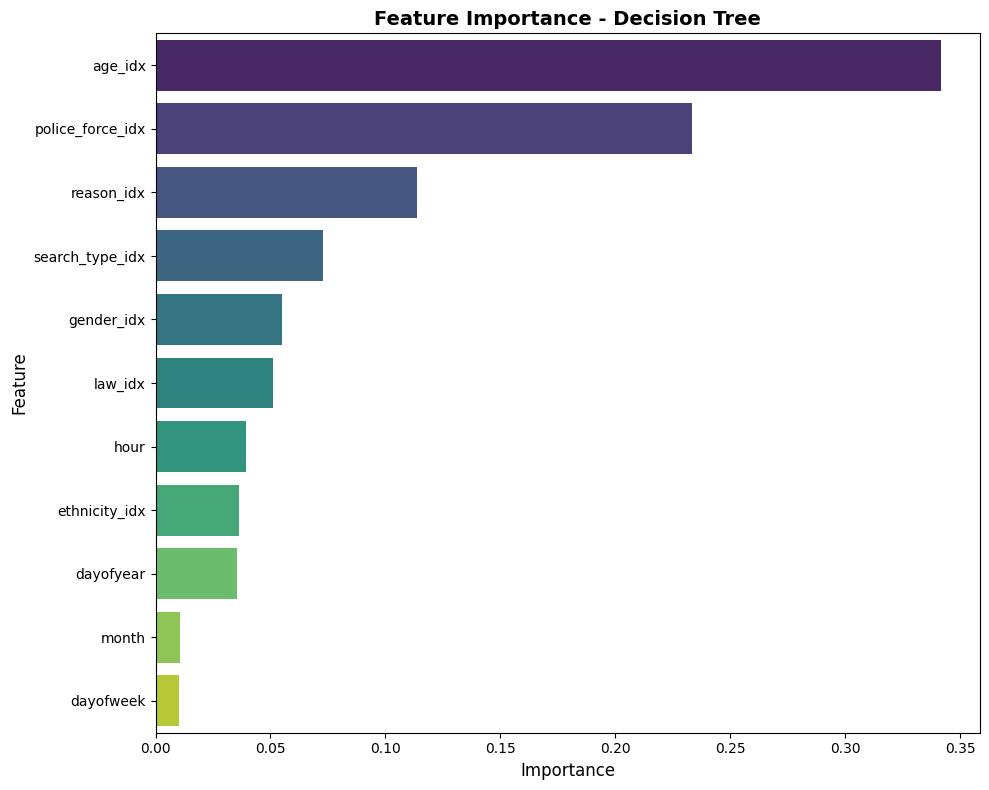


Total features: 11
Top feature: age_idx (0.3416)
Top 5 features account for: 81.67% of total importance

✓ Feature importance saved to 'feature_importance.csv'


Test data size: 80834
Class distribution (training): Neg=72.23%, Pos=27.77%



THRESHOLD-INDEPENDENT METRICS
AUC-ROC: 0.6523
AUC-PR : 0.4060



TRAINED MODEL METRICS (threshold=0.535)
Accuracy:           0.6312
Weighted Precision: 0.6732
Weighted Recall:    0.6312
Weighted F1 Score:  0.6454


/home/alumno/py313ml/.venv/lib/python3.13/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
                                                                                

...


  Class 0 (support=57716):


    Precision: 0.7847
    Recall:    0.6664
    F1-Score:  0.7207



  Class 1 (support=23118):
    Precision: 0.3949
    Recall:    0.5436
    F1-Score:  0.4574



NAIVE BASELINE MODEL


Random predictions with P(class=1)=27.77%
Accuracy:           0.5943
Weighted Precision: 0.5902
Weighted Recall:    0.5943
Weighted F1 Score:  0.5922


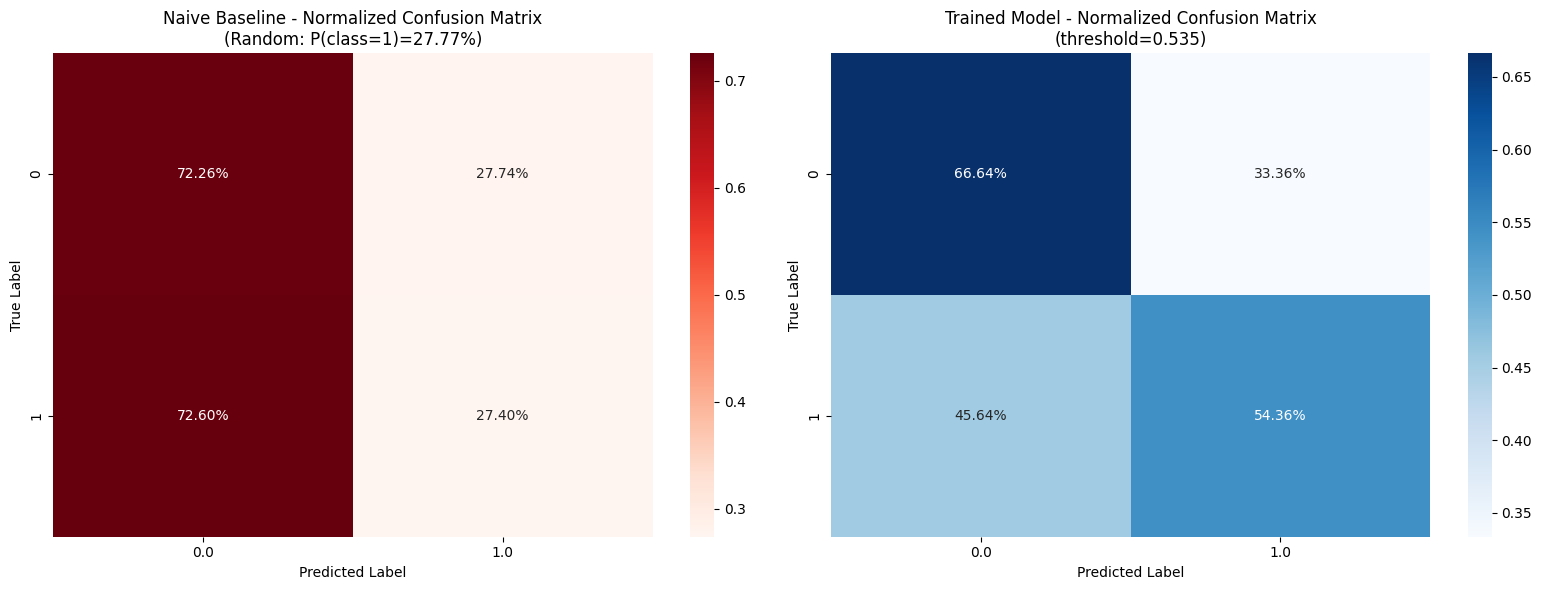


MODEL COMPARISON
Metric                 Trained      Baseline     Δ Improvement  
------------------------------------------------------------
Accuracy               0.6312       0.5943       +0.0370        
Weighted F1            0.6454       0.5922       +0.0532        
Weighted Precision     0.6732       0.5902       +0.0830        
Weighted Recall        0.6312       0.5943       +0.0370        
AUC-ROC                0.6523       ~0.5000      +0.1523        
*************** mult factor:  1 ***************
 Unbalance: 229,536 negatives vs 86,410 positives
   Ratio: 0.73 vs 0.27

Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 15.59 seconds.

                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
         age_idx    0.271360
         law_idx    0.267669
police_force_idx    0.189608
      reason_idx    0.133223
      gender_idx    0.034629
            hour    0.025100
 search_type_idx    0.023972
       dayofyear    0.022740
   ethnicity_idx    0.012506
           month    0.011252
       dayofweek    0.007938


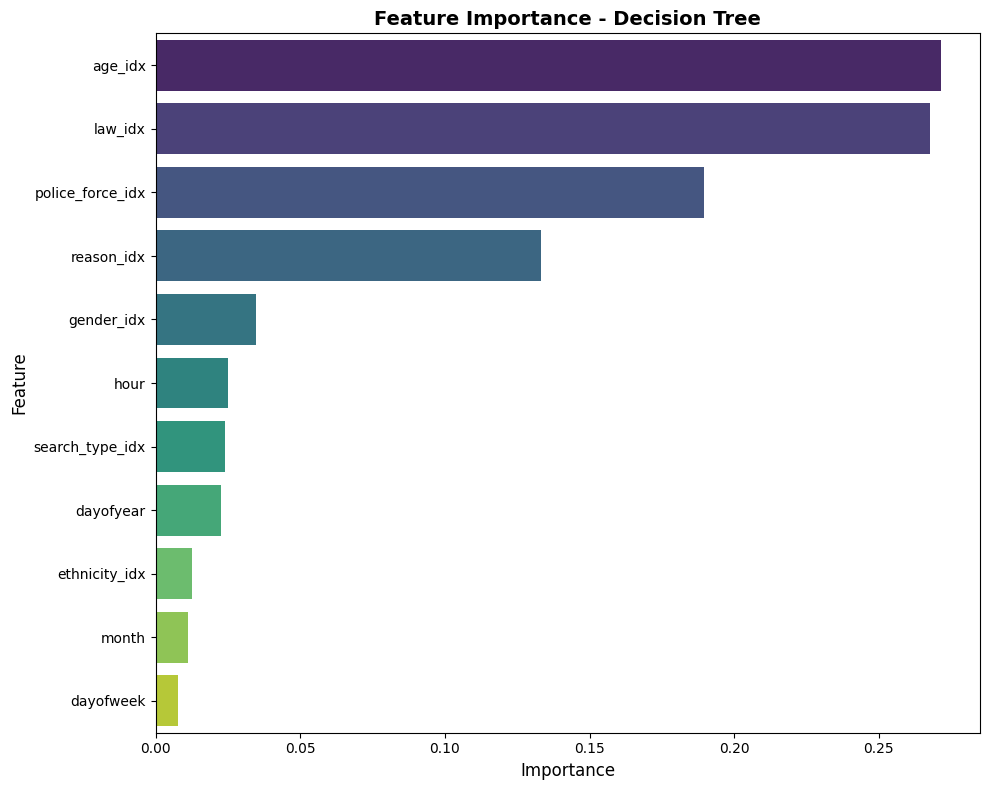


Total features: 11
Top feature: age_idx (0.2714)
Top 5 features account for: 89.65% of total importance

✓ Feature importance saved to 'feature_importance.csv'


Test data size: 71375
Class distribution (training): Neg=72.65%, Pos=27.35%



THRESHOLD-INDEPENDENT METRICS
AUC-ROC: 0.6973
AUC-PR : 0.4328



TRAINED MODEL METRICS (threshold=0.535)
Accuracy:           0.6166
Weighted Precision: 0.7084
Weighted Recall:    0.6166
Weighted F1 Score:  0.6360


/home/alumno/py313ml/.venv/lib/python3.13/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
                                                                                

...


  Class 0 (support=51324):


    Precision: 0.8305
    Recall:    0.5865
    F1-Score:  0.6875



  Class 1 (support=20051):
    Precision: 0.3959
    Recall:    0.6936
    F1-Score:  0.5041



NAIVE BASELINE MODEL


Random predictions with P(class=1)=27.35%
Accuracy:           0.5997
Weighted Precision: 0.5963
Weighted Recall:    0.5997
Weighted F1 Score:  0.5980


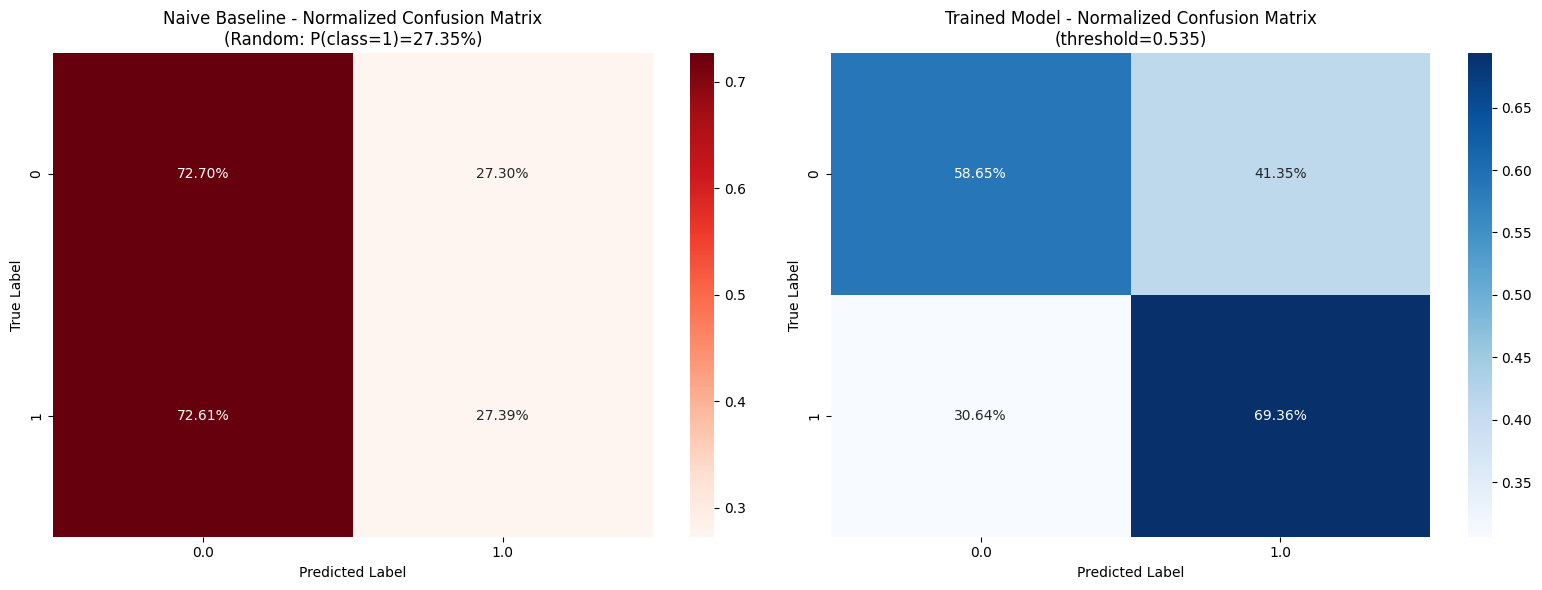


MODEL COMPARISON
Metric                 Trained      Baseline     Δ Improvement  
------------------------------------------------------------
Accuracy               0.6166       0.5997       +0.0169        
Weighted F1            0.6360       0.5980       +0.0380        
Weighted Precision     0.7084       0.5963       +0.1121        
Weighted Recall        0.6166       0.5997       +0.0169        
AUC-ROC                0.6973       ~0.5000      +0.1973        


In [18]:
fractions = {
    2022: 0.8,
    2023: 0.8,
    2024: 0.8,
    2025: 0.8
}

# Muestreo estratificado
train_df = df_final.sampleBy("year", fractions, seed=42)

# El test set son los registros que NO están en train
test_df = df_final.join(train_df, on=df_final.columns, how="left_anti")

for year in [2023, 2024, 2025]:
    if year == 2023:
        train_df_objective = (
            train_df.filter(
                F.col("year") <= year
            )
        )
        
        test_df_objective = (
            test_df.filter(
                F.col("year") <= year
            )
        )
    else:
        train_df_objective = (
            train_df.filter(
                F.col("year") == year
            )
        )
        
        test_df_objective = (
            test_df.filter(
                F.col("year") == year
            )
        )

    mult = 1
    print("*"*15, "mult factor: ", mult, "*"*15)
    trained_pipeline, neg_count, pos_count = train_dt(
        train_df_objective,
        categorical_cols, 
        numeric_cols,
        feature_cols,
        normalized_weights=True,
        weight_multiplier = mult,
        model = "RF"
    )

    trained_model = trained_pipeline.stages[-1]
    
    show_importances(
        trained_model,
        categorical_cols,
        numeric_cols,
        feature_cols
    )

    # for thres in np.arange(0.7, 0.8, 0.03):
    calculate_metrics(
        trained_pipeline,
        test_df_objective,
        neg_count,
        pos_count,
        threshold = 0.535
    )

# Appending data

## Decision Tree

*************** mult factor:  1 ***************
 Unbalance: 329,459 negatives vs 116,293 positives
   Ratio: 0.74 vs 0.26

Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 10.64 seconds.

                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
police_force_idx    0.374342
         age_idx    0.336351
      reason_idx    0.084672
 search_type_idx    0.051107
            hour    0.036727
         law_idx    0.035355
       dayofyear    0.032092
      gender_idx    0.025844
   ethnicity_idx    0.013788
       dayofweek    0.005915
           month    0.003806


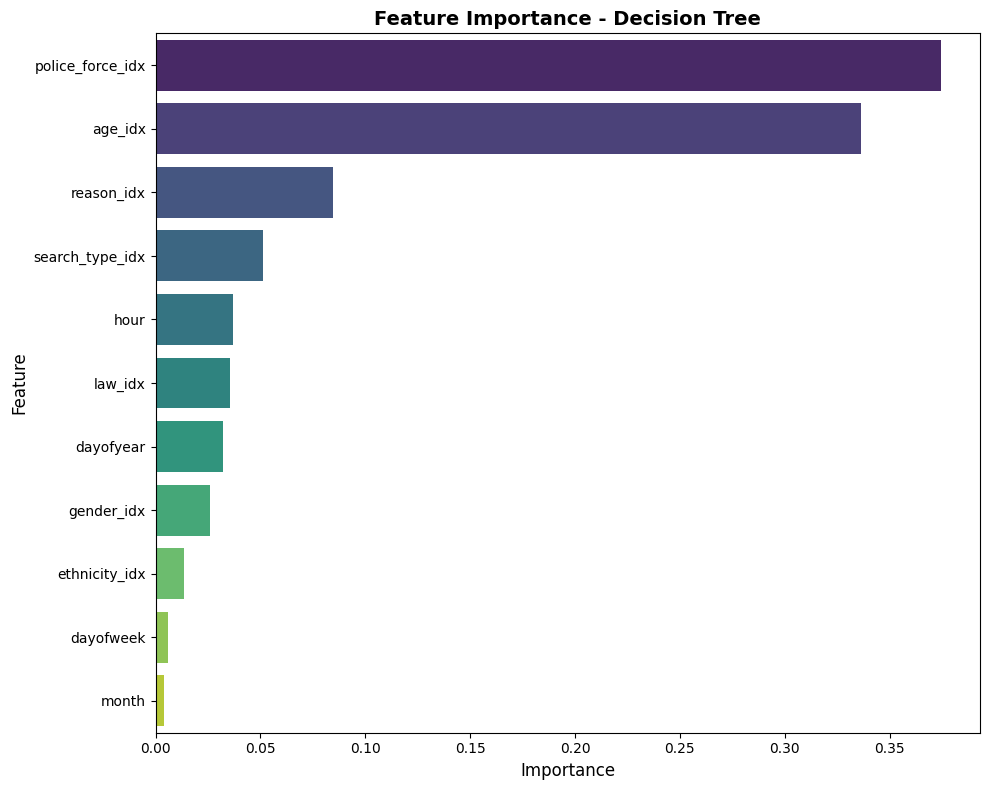


Total features: 11
Top feature: police_force_idx (0.3743)
Top 5 features account for: 88.32% of total importance

✓ Feature importance saved to 'feature_importance.csv'


Test data size: 99378
Class distribution (training): Neg=73.91%, Pos=26.09%



THRESHOLD-INDEPENDENT METRICS
AUC-ROC: 0.5750
AUC-PR : 0.3104



TRAINED MODEL METRICS (threshold=0.535)
Accuracy:           0.6178
Weighted Precision: 0.6740
Weighted Recall:    0.6178
Weighted F1 Score:  0.6363


/home/alumno/py313ml/.venv/lib/python3.13/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
                                                                                

...


  Class 0 (support=72665):


    Precision: 0.7902
    Recall:    0.6497
    F1-Score:  0.7131



  Class 1 (support=26713):
    Precision: 0.3578
    Recall:    0.5308
    F1-Score:  0.4274



NAIVE BASELINE MODEL


Random predictions with P(class=1)=26.09%
Accuracy:           0.6123
Weighted Precision: 0.6081
Weighted Recall:    0.6123
Weighted F1 Score:  0.6101


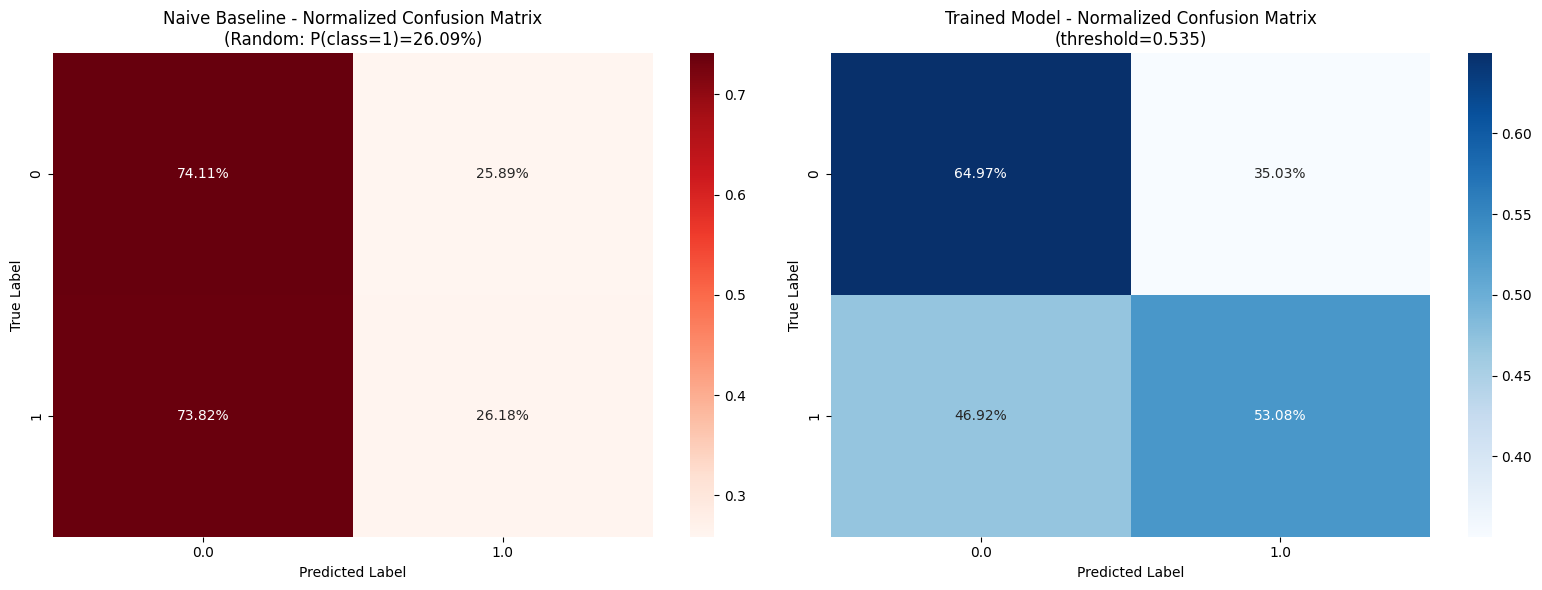


MODEL COMPARISON
Metric                 Trained      Baseline     Δ Improvement  
------------------------------------------------------------
Accuracy               0.6178       0.6123       +0.0055        
Weighted F1            0.6363       0.6101       +0.0262        
Weighted Precision     0.6740       0.6081       +0.0659        
Weighted Recall        0.6178       0.6123       +0.0055        
AUC-ROC                0.5750       ~0.5000      +0.0750        
*************** mult factor:  1 ***************
 Unbalance: 590,515 negatives vs 216,666 positives
   Ratio: 0.73 vs 0.27

Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 13.88 seconds.

                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
police_force_idx    0.394514
         age_idx    0.339202
      reason_idx    0.072081
 search_type_idx    0.055679
         law_idx    0.053195
            hour    0.029466
      gender_idx    0.026572
       dayofyear    0.013497
   ethnicity_idx    0.009673
       dayofweek    0.004142
           month    0.001979


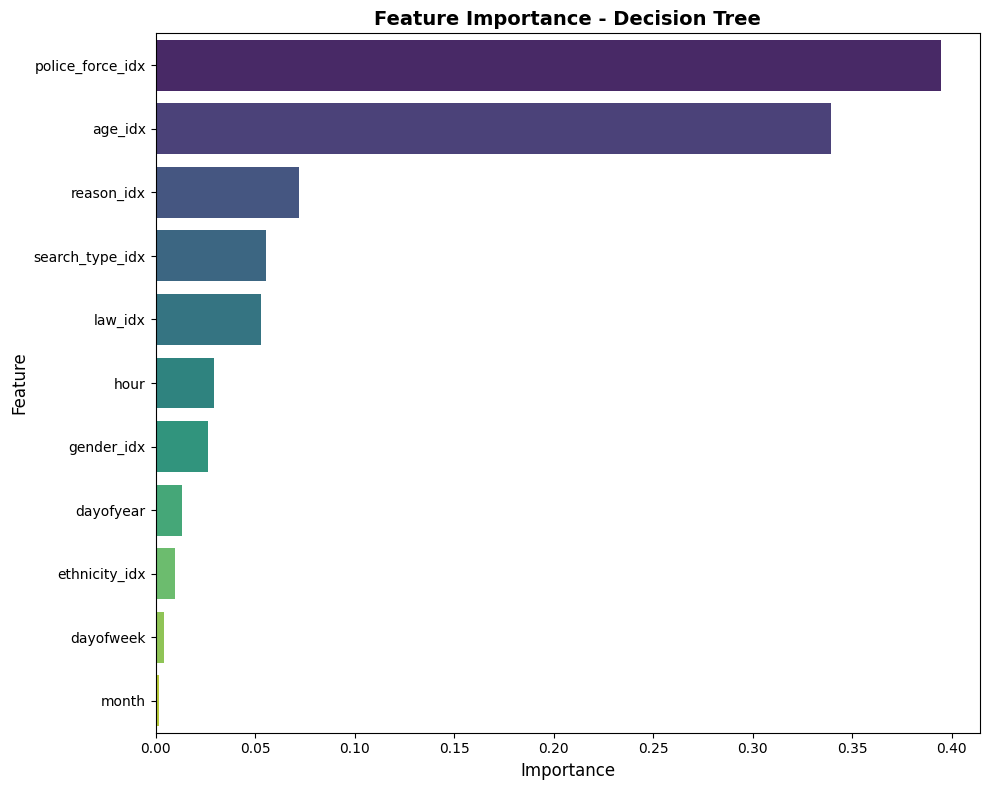


Total features: 11
Top feature: police_force_idx (0.3945)
Top 5 features account for: 91.47% of total importance

✓ Feature importance saved to 'feature_importance.csv'


Test data size: 80834
Class distribution (training): Neg=73.16%, Pos=26.84%



THRESHOLD-INDEPENDENT METRICS
AUC-ROC: 0.5672
AUC-PR : 0.3251



TRAINED MODEL METRICS (threshold=0.535)
Accuracy:           0.6062
Weighted Precision: 0.6716
Weighted Recall:    0.6062
Weighted F1 Score:  0.6244


/home/alumno/py313ml/.venv/lib/python3.13/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
                                                                                

...


  Class 0 (support=57716):


    Precision: 0.7887
    Recall:    0.6125
    F1-Score:  0.6895



  Class 1 (support=23118):
    Precision: 0.3790
    Recall:    0.5904
    F1-Score:  0.4617



NAIVE BASELINE MODEL


Random predictions with P(class=1)=26.84%
Accuracy:           0.5959
Weighted Precision: 0.5895
Weighted Recall:    0.5959
Weighted F1 Score:  0.5926


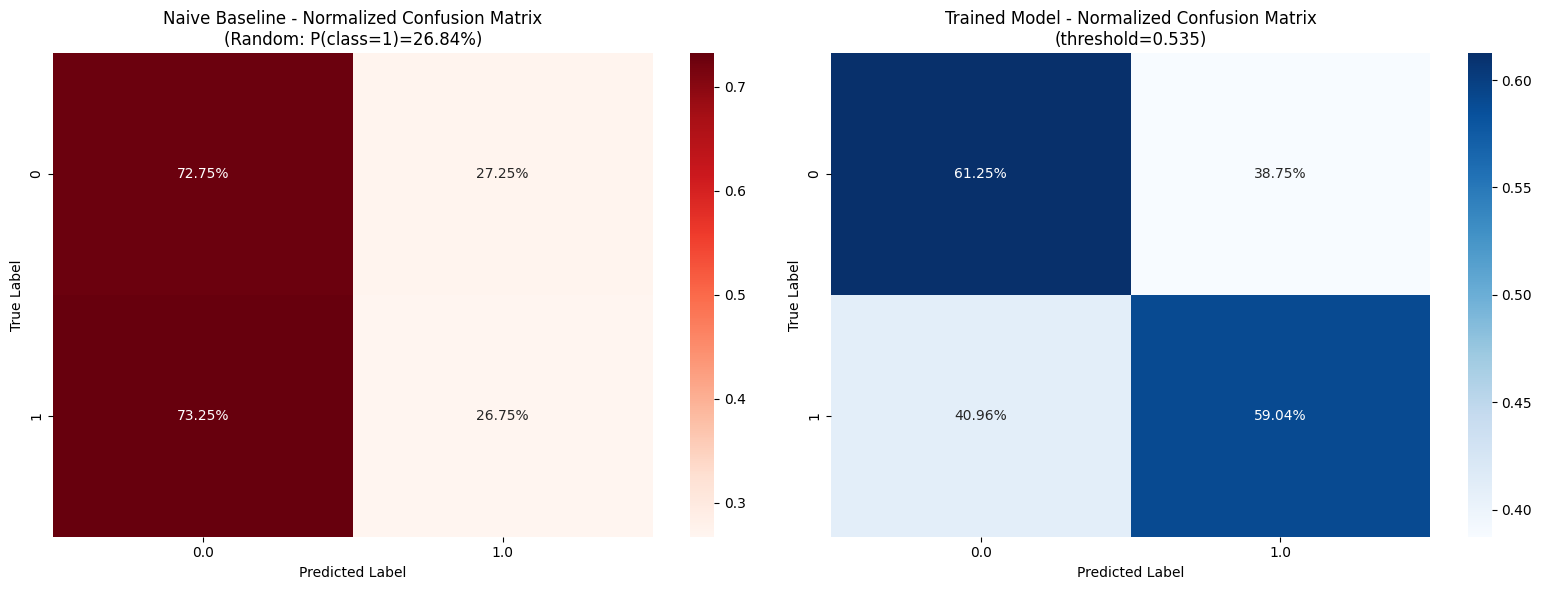


MODEL COMPARISON
Metric                 Trained      Baseline     Δ Improvement  
------------------------------------------------------------
Accuracy               0.6062       0.5959       +0.0103        
Weighted F1            0.6244       0.5926       +0.0318        
Weighted Precision     0.6716       0.5895       +0.0821        
Weighted Recall        0.6062       0.5959       +0.0103        
AUC-ROC                0.5672       ~0.5000      +0.0672        
*************** mult factor:  1 ***************
 Unbalance: 820,051 negatives vs 303,076 positives
   Ratio: 0.73 vs 0.27

Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 17.85 seconds.

                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
police_force_idx    0.351632
         age_idx    0.319176
         law_idx    0.139280
      reason_idx    0.073238
 search_type_idx    0.042105
      gender_idx    0.035025
            hour    0.017472
       dayofyear    0.010154
   ethnicity_idx    0.008215
       dayofweek    0.003193
           month    0.000509


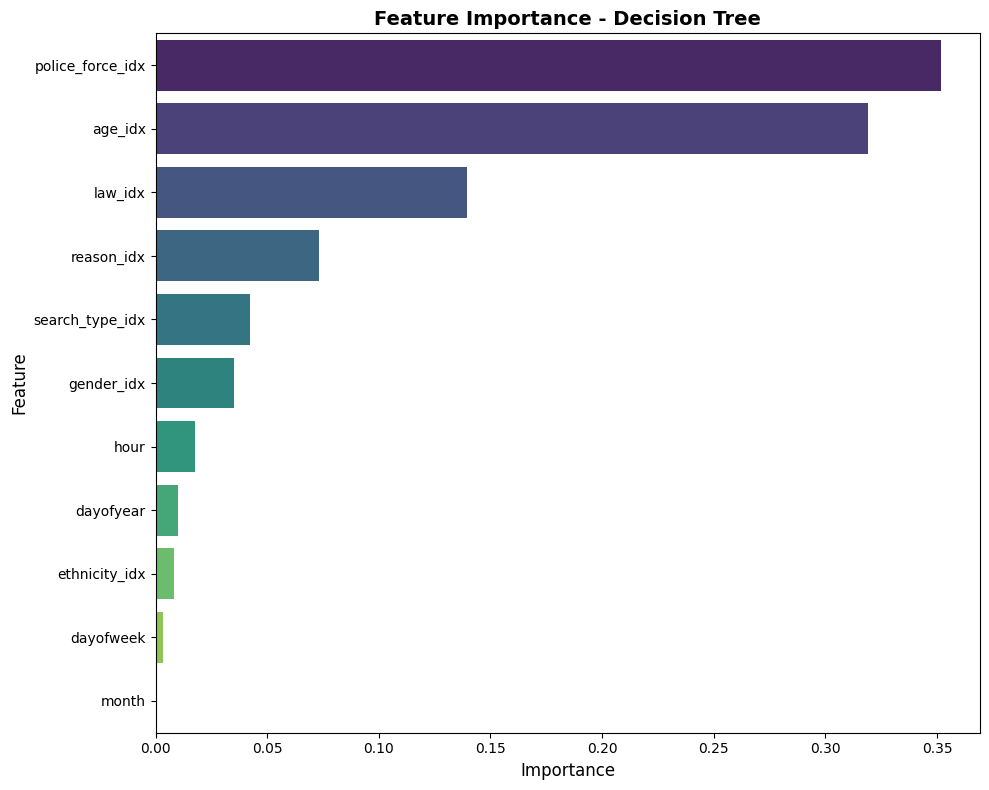


Total features: 11
Top feature: police_force_idx (0.3516)
Top 5 features account for: 92.54% of total importance

✓ Feature importance saved to 'feature_importance.csv'


Test data size: 71375
Class distribution (training): Neg=73.01%, Pos=26.99%



THRESHOLD-INDEPENDENT METRICS
AUC-ROC: 0.6397
AUC-PR : 0.3630



TRAINED MODEL METRICS (threshold=0.535)
Accuracy:           0.6206
Weighted Precision: 0.6989
Weighted Recall:    0.6206
Weighted F1 Score:  0.6395


/home/alumno/py313ml/.venv/lib/python3.13/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
                                                                                

...


  Class 0 (support=51324):


    Precision: 0.8179
    Recall:    0.6076
    F1-Score:  0.6972



  Class 1 (support=20051):
    Precision: 0.3942
    Recall:    0.6537
    F1-Score:  0.4918



NAIVE BASELINE MODEL


Random predictions with P(class=1)=26.99%
Accuracy:           0.6023
Weighted Precision: 0.5978
Weighted Recall:    0.6023
Weighted F1 Score:  0.6000


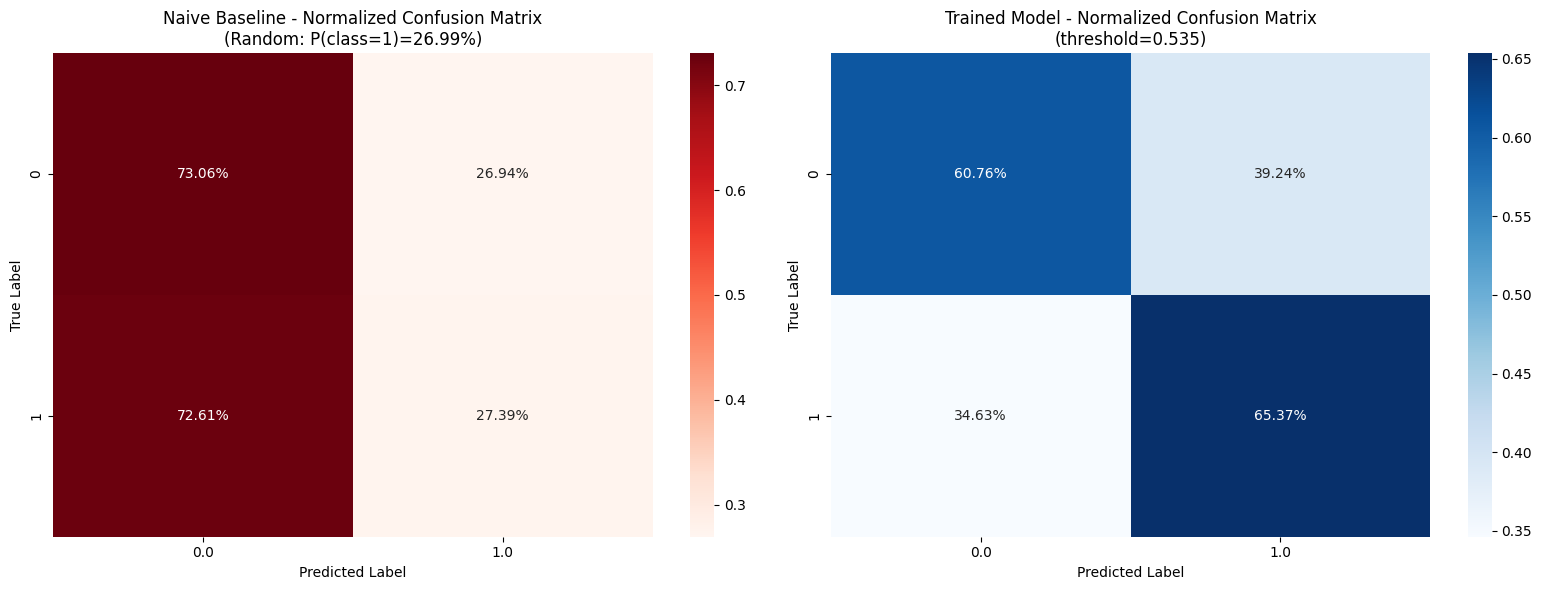


MODEL COMPARISON
Metric                 Trained      Baseline     Δ Improvement  
------------------------------------------------------------
Accuracy               0.6206       0.6023       +0.0182        
Weighted F1            0.6395       0.6000       +0.0395        
Weighted Precision     0.6989       0.5978       +0.1010        
Weighted Recall        0.6206       0.6023       +0.0182        
AUC-ROC                0.6397       ~0.5000      +0.1397        


In [19]:
fractions = {
    2022: 0.8,
    2023: 0.8,
    2024: 0.8,
    2025: 0.8
}

# Muestreo estratificado
train_df = df_final.sampleBy("year", fractions, seed=42)

# El test set son los registros que NO están en train
test_df = df_final.join(train_df, on=df_final.columns, how="left_anti")

for year in [2023, 2024, 2025]:
    if year == 2023:
        train_df_objective = (
            train_df.filter(
                F.col("year") <= year
            )
        )
        
        test_df_objective = (
            test_df.filter(
                F.col("year") <= year
            )
        )
    else:
        train_df_objective = (
            train_df.filter(
                F.col("year") <= year
            )
        )
        
        test_df_objective = (
            test_df.filter(
                F.col("year") == year
            )
        )

    mult = 1
    print("*"*15, "mult factor: ", mult, "*"*15)
    trained_pipeline, neg_count, pos_count = train_dt(
        train_df_objective,
        categorical_cols, 
        numeric_cols,
        feature_cols,
        normalized_weights=True,
        weight_multiplier = mult,
        model = "DT"
    )

    trained_model = trained_pipeline.stages[-1]
    
    show_importances(
        trained_model,
        categorical_cols,
        numeric_cols,
        feature_cols
    )

    # for thres in np.arange(0.7, 0.8, 0.03):
    calculate_metrics(
        trained_pipeline,
        test_df_objective,
        neg_count,
        pos_count,
        threshold = 0.535
    )

## Random Forest

*************** mult factor:  1 ***************


 Unbalance: 329,459 negatives vs 116,293 positives
   Ratio: 0.74 vs 0.26

Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 14.91 seconds.

                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
         age_idx    0.365455
police_force_idx    0.222731
 search_type_idx    0.097270
      reason_idx    0.088197
         law_idx    0.068387
            hour    0.047862
      gender_idx    0.030128
       dayofyear    0.027886
   ethnicity_idx    0.027544
           month    0.012939
       dayofweek    0.011599


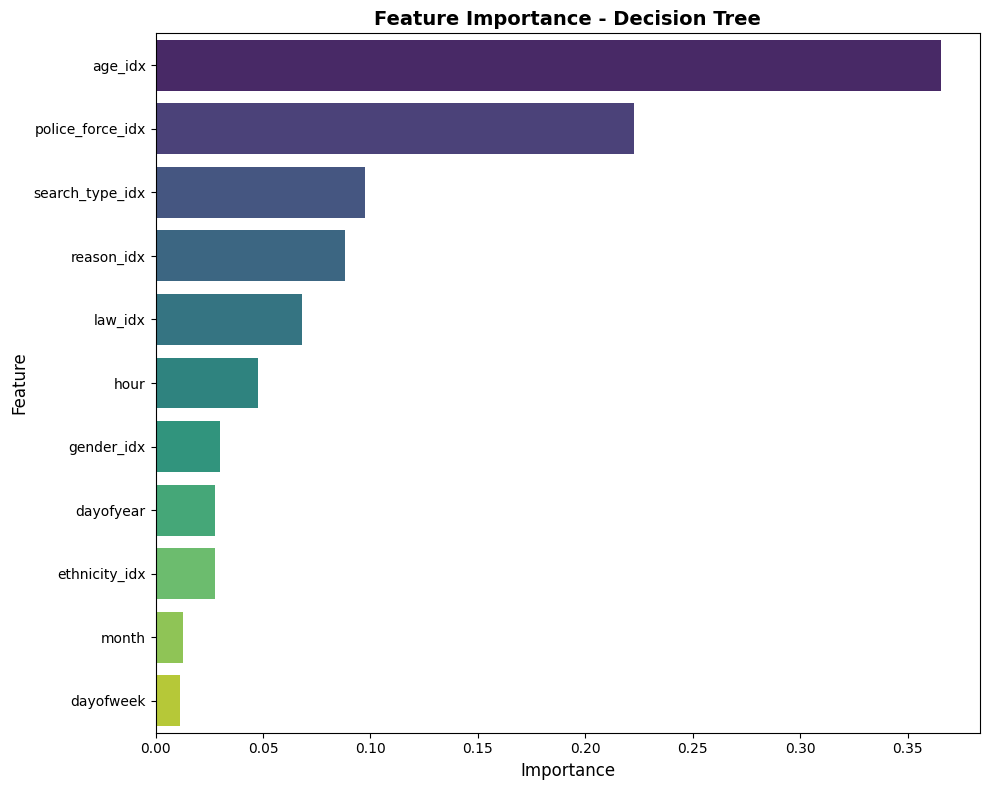


Total features: 11
Top feature: age_idx (0.3655)
Top 5 features account for: 84.20% of total importance

✓ Feature importance saved to 'feature_importance.csv'


Test data size: 99378
Class distribution (training): Neg=73.91%, Pos=26.09%



THRESHOLD-INDEPENDENT METRICS
AUC-ROC: 0.6455
AUC-PR : 0.3749



TRAINED MODEL METRICS (threshold=0.535)
Accuracy:           0.6313
Weighted Precision: 0.6784
Weighted Recall:    0.6313
Weighted F1 Score:  0.6477


/home/alumno/py313ml/.venv/lib/python3.13/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
                                                                                

...


  Class 0 (support=72665):


    Precision: 0.7924
    Recall:    0.6718
    F1-Score:  0.7271



  Class 1 (support=26713):
    Precision: 0.3685
    Recall:    0.5211
    F1-Score:  0.4318



NAIVE BASELINE MODEL


Random predictions with P(class=1)=26.09%
Accuracy:           0.6106
Weighted Precision: 0.6062
Weighted Recall:    0.6106
Weighted F1 Score:  0.6083


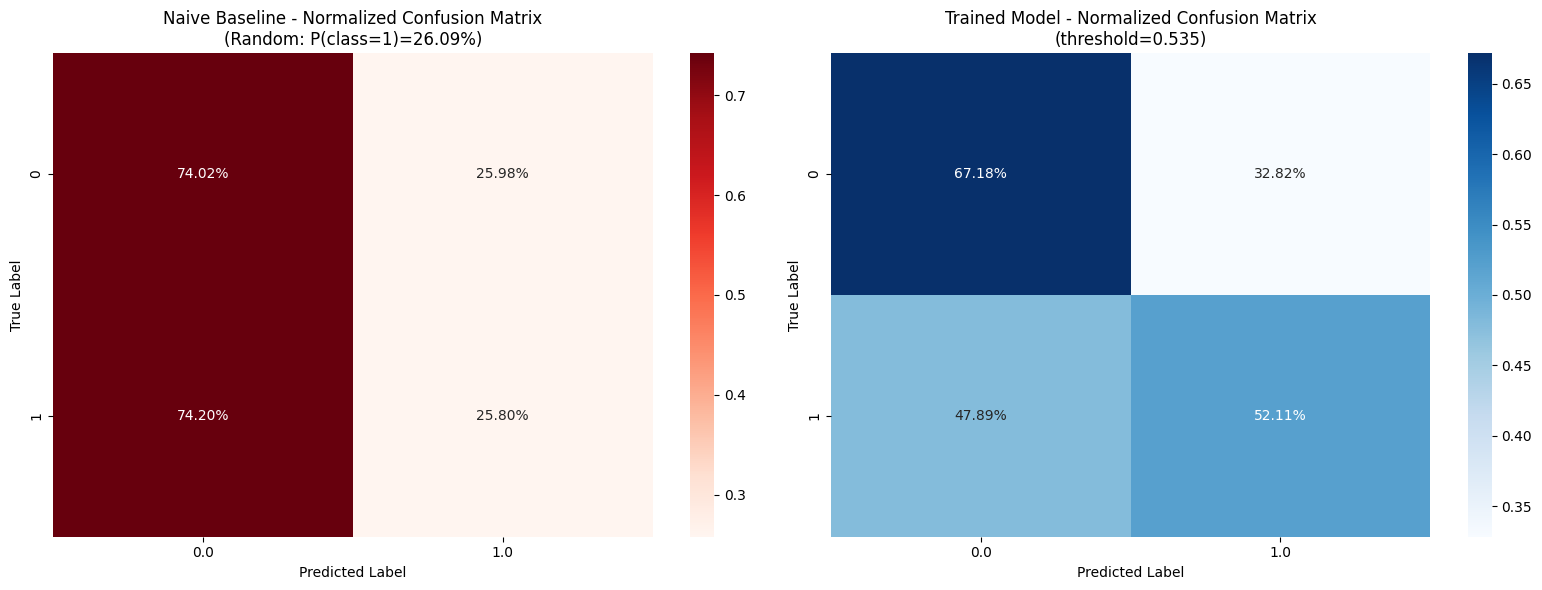


MODEL COMPARISON
Metric                 Trained      Baseline     Δ Improvement  
------------------------------------------------------------
Accuracy               0.6313       0.6106       +0.0207        
Weighted F1            0.6477       0.6083       +0.0394        
Weighted Precision     0.6784       0.6062       +0.0722        
Weighted Recall        0.6313       0.6106       +0.0207        
AUC-ROC                0.6455       ~0.5000      +0.1455        
*************** mult factor:  1 ***************
 Unbalance: 590,515 negatives vs 216,666 positives
   Ratio: 0.73 vs 0.27

Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 19.34 seconds.

                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
         age_idx    0.404826
police_force_idx    0.225485
      reason_idx    0.096636
 search_type_idx    0.095647
         law_idx    0.048657
            hour    0.033558
      gender_idx    0.032999
   ethnicity_idx    0.030685
       dayofyear    0.017629
           month    0.007425
       dayofweek    0.006452


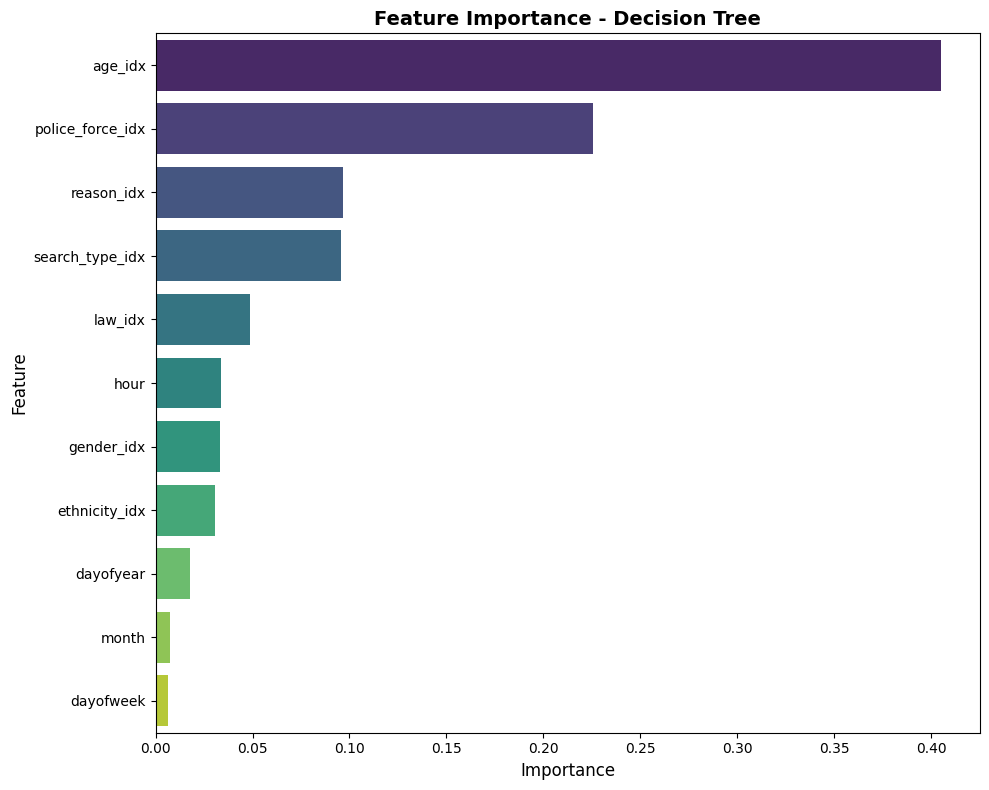


Total features: 11
Top feature: age_idx (0.4048)
Top 5 features account for: 87.13% of total importance

✓ Feature importance saved to 'feature_importance.csv'


Test data size: 80834
Class distribution (training): Neg=73.16%, Pos=26.84%



THRESHOLD-INDEPENDENT METRICS
AUC-ROC: 0.6505
AUC-PR : 0.4029



TRAINED MODEL METRICS (threshold=0.535)
Accuracy:           0.6351
Weighted Precision: 0.6723
Weighted Recall:    0.6351
Weighted F1 Score:  0.6482


/home/alumno/py313ml/.venv/lib/python3.13/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
                                                                                

...


  Class 0 (support=57716):


    Precision: 0.7826
    Recall:    0.6768
    F1-Score:  0.7259



  Class 1 (support=23118):
    Precision: 0.3968
    Recall:    0.5307
    F1-Score:  0.4541



NAIVE BASELINE MODEL


Random predictions with P(class=1)=26.84%
Accuracy:           0.5995
Weighted Precision: 0.5925
Weighted Recall:    0.5995
Weighted F1 Score:  0.5958


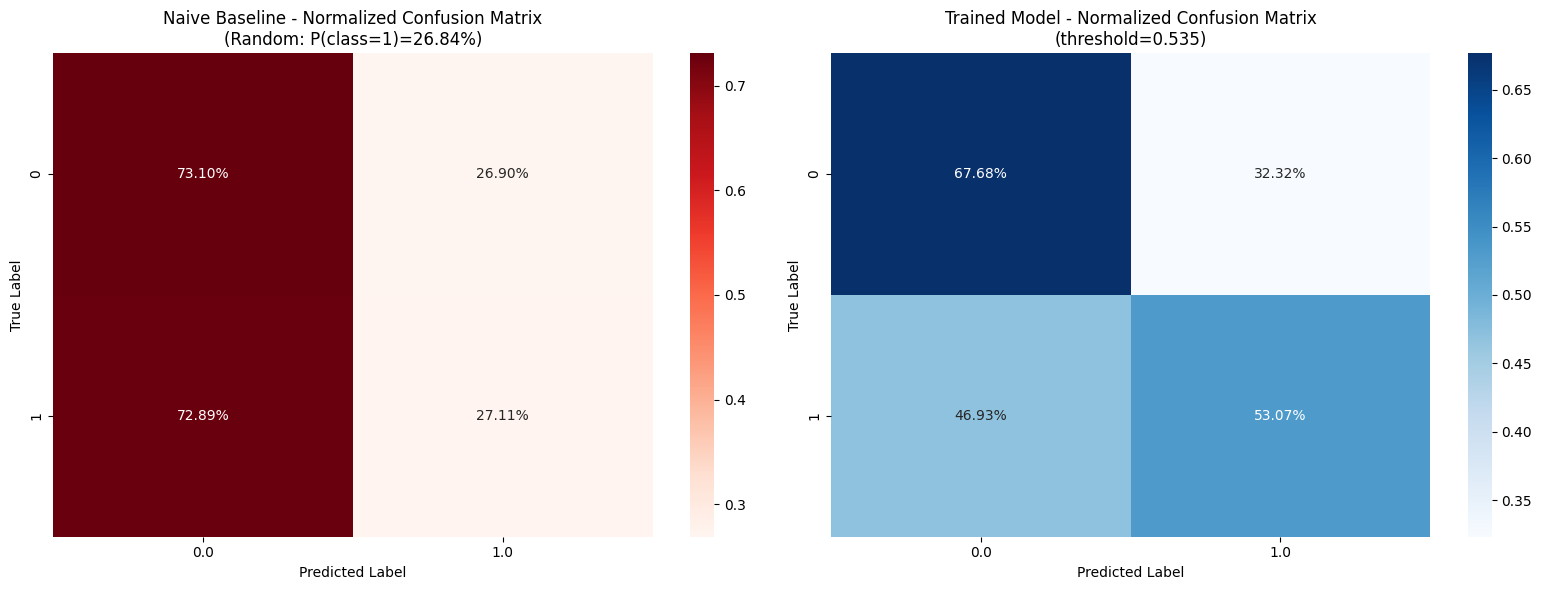


MODEL COMPARISON
Metric                 Trained      Baseline     Δ Improvement  
------------------------------------------------------------
Accuracy               0.6351       0.5995       +0.0356        
Weighted F1            0.6482       0.5958       +0.0523        
Weighted Precision     0.6723       0.5925       +0.0798        
Weighted Recall        0.6351       0.5995       +0.0356        
AUC-ROC                0.6505       ~0.5000      +0.1505        
*************** mult factor:  1 ***************
 Unbalance: 820,051 negatives vs 303,076 positives
   Ratio: 0.73 vs 0.27

Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 27.18 seconds.

                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
         age_idx    0.364932
police_force_idx    0.211458
         law_idx    0.138728
      reason_idx    0.128906
 search_type_idx    0.047977
      gender_idx    0.035509
   ethnicity_idx    0.028537
            hour    0.021922
       dayofyear    0.013338
           month    0.004618
       dayofweek    0.004075


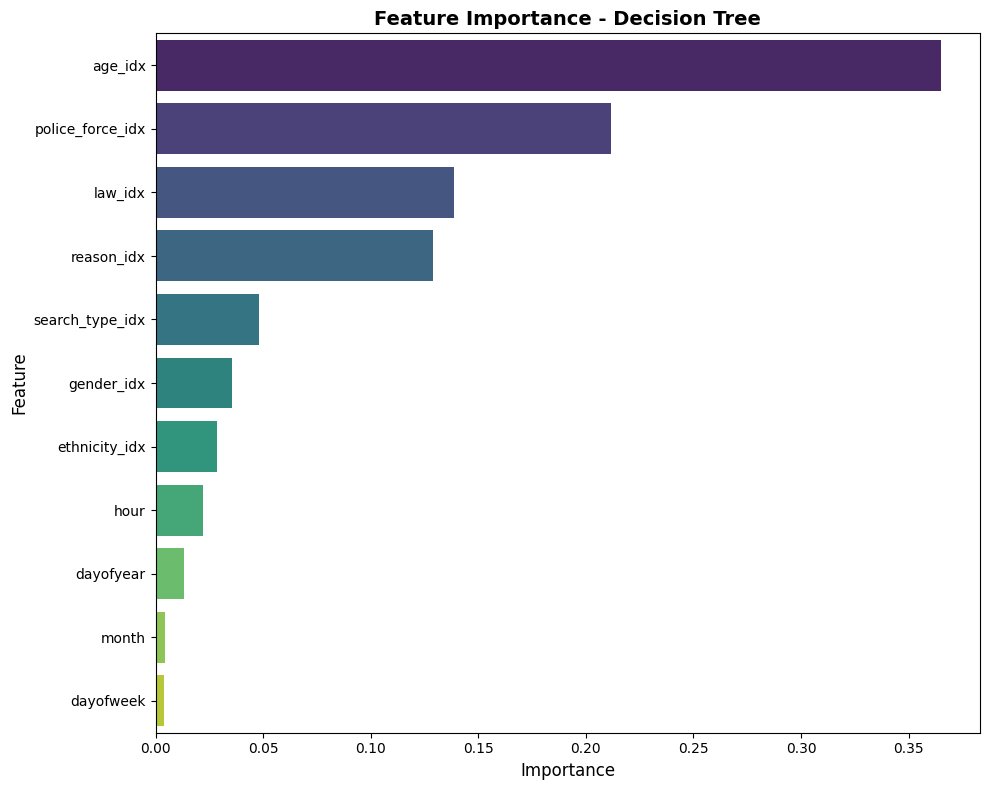


Total features: 11
Top feature: age_idx (0.3649)
Top 5 features account for: 89.20% of total importance

✓ Feature importance saved to 'feature_importance.csv'


Test data size: 71375
Class distribution (training): Neg=73.01%, Pos=26.99%



THRESHOLD-INDEPENDENT METRICS
AUC-ROC: 0.6964
AUC-PR : 0.4295



TRAINED MODEL METRICS (threshold=0.535)
Accuracy:           0.6397
Weighted Precision: 0.6977
Weighted Recall:    0.6397
Weighted F1 Score:  0.6564


/home/alumno/py313ml/.venv/lib/python3.13/site-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
                                                                                

...


  Class 0 (support=51324):


    Precision: 0.8114
    Recall:    0.6500
    F1-Score:  0.7218



  Class 1 (support=20051):
    Precision: 0.4064
    Recall:    0.6133
    F1-Score:  0.4889



NAIVE BASELINE MODEL


Random predictions with P(class=1)=26.99%
Accuracy:           0.6029
Weighted Precision: 0.5972
Weighted Recall:    0.6029
Weighted F1 Score:  0.6000


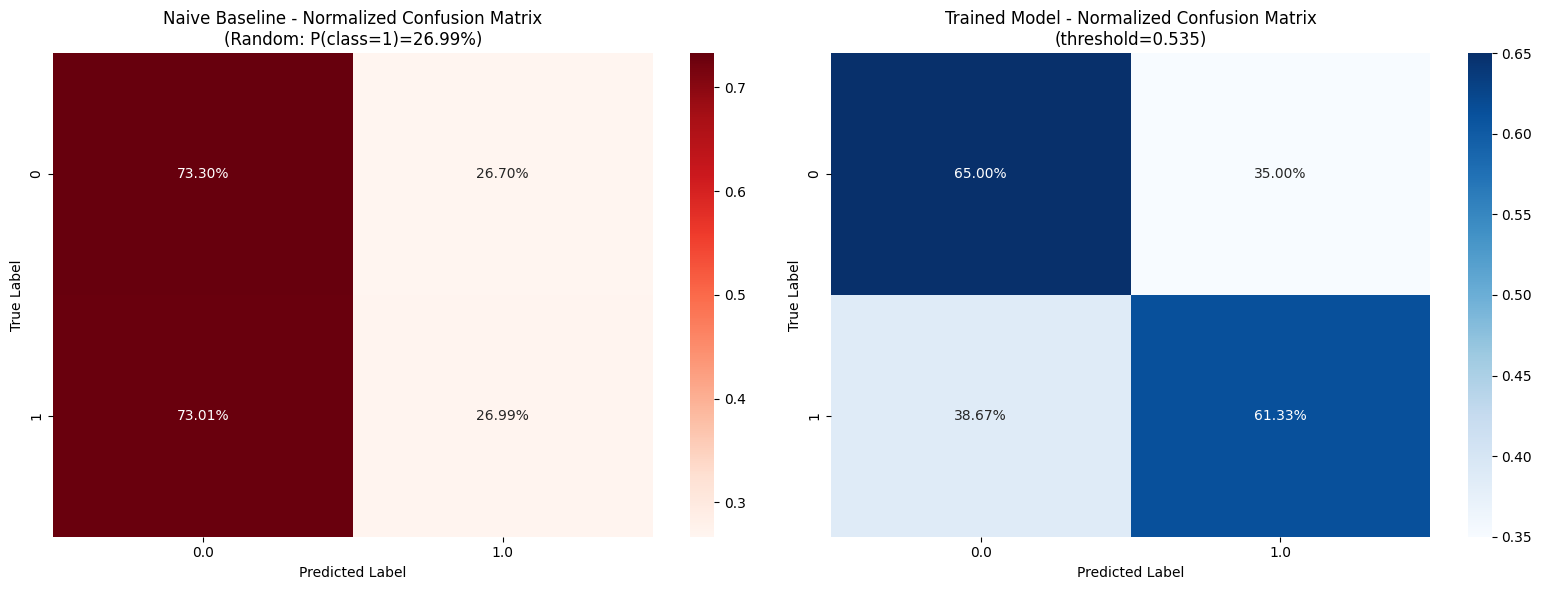


MODEL COMPARISON
Metric                 Trained      Baseline     Δ Improvement  
------------------------------------------------------------
Accuracy               0.6397       0.6029       +0.0368        
Weighted F1            0.6564       0.6000       +0.0564        
Weighted Precision     0.6977       0.5972       +0.1005        
Weighted Recall        0.6397       0.6029       +0.0368        
AUC-ROC                0.6964       ~0.5000      +0.1964        


In [20]:
fractions = {
    2022: 0.8,
    2023: 0.8,
    2024: 0.8,
    2025: 0.8
}

# Muestreo estratificado
train_df = df_final.sampleBy("year", fractions, seed=42)

# El test set son los registros que NO están en train
test_df = df_final.join(train_df, on=df_final.columns, how="left_anti")

for year in [2023, 2024, 2025]:
    if year == 2023:
        train_df_objective = (
            train_df.filter(
                F.col("year") <= year
            )
        )
        
        test_df_objective = (
            test_df.filter(
                F.col("year") <= year
            )
        )
    else:
        train_df_objective = (
            train_df.filter(
                F.col("year") <= year
            )
        )
        
        test_df_objective = (
            test_df.filter(
                F.col("year") == year
            )
        )

    mult = 1
    print("*"*15, "mult factor: ", mult, "*"*15)
    trained_pipeline, neg_count, pos_count = train_dt(
        train_df_objective,
        categorical_cols, 
        numeric_cols,
        feature_cols,
        normalized_weights=True,
        weight_multiplier = mult,
        model = "RF"
    )

    trained_model = trained_pipeline.stages[-1]
    
    show_importances(
        trained_model,
        categorical_cols,
        numeric_cols,
        feature_cols
    )

    # for thres in np.arange(0.7, 0.8, 0.03):
    calculate_metrics(
        trained_pipeline,
        test_df_objective,
        neg_count,
        pos_count,
        threshold = 0.535
    )